**Table of contents**
1. [Set up and config](#1)
2. [Xử lý dữ liệu và EDA](#2)
3. [Mô hình và huấn luyện mô hình](#3)
4. [Đánh giá mô hình](#4)

# 1. Set up and config <a id='1'></a>

In [1]:
import time
from dataclasses import asdict, is_dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
from config import (
  SEED, ALPHA, DATA_PATH, TARGET_COL, TEST_SIZE, VAL_SIZE,
  BINARY_CLASSES, BINARY_FEATURE_INDICES, KFOLD_SPLITS, N_BINS,
  GaussianNaiveBayesConfig,
  KernelLogisticRegressionConfig,
  LDAConfig,
  LogisticRegressionConfig,
  PerceptronConfig,
  ProbitRegressionConfig,
  QDAConfig,
  SoftmaxRegressionConfig,
)
from preprocessing import prepare_classification_data, make_binary_subset
from tuning import tune_logistic_regularization
from eda import (
  summarize_dataset,
  summarize_numeric_statistics,
  plot_class_distribution,
  plot_correlation_heatmap,
  plot_top_feature_distributions,
)
from experiments import (
  fisher_ratio_ranking,
  ovr_predict_with_logistic,
  ovo_predict_with_logistic,
  run_perceptron_toy_convergence,
)
from eval import (
  classification_report,
  collect_models_with_attr,
  compare_average_precision,
  evaluate_multiclass_strategy,
  kfold_cross_val_score,
  mcnemar_paired,
  plot_loss_curves,
  plot_loss_curves_separately,
  plot_roc_curve,
  reliability_diagram_multiclass,
  sparsity_ratio,
)
import utils as utils_module
from models import (
  GaussianNaiveBayes,
  KernelLogisticRegression,
  LDA,
  LogisticRegression,
  Perceptron,
  ProbitRegression,
  QDA,
  SoftmaxRegression,
)

# Base configs from config.py
logreg_cfg = LogisticRegressionConfig()
softmax_cfg = SoftmaxRegressionConfig()
perceptron_cfg = PerceptronConfig()
probit_cfg = ProbitRegressionConfig()
kernel_log_cfg = KernelLogisticRegressionConfig()
lda_cfg = LDAConfig()
qda_cfg = QDAConfig()
gnb_cfg = GaussianNaiveBayesConfig()

# Notebook-specific overrides for LR regularization experiments
logreg_l1_cfg = LogisticRegressionConfig(l1_penalty=1e-3)
logreg_l2_cfg = LogisticRegressionConfig(l2_penalty=1e-3)
logreg_elastic_cfg = LogisticRegressionConfig(l1_penalty=5e-4, l2_penalty=5e-4)

def build_from_config(model_cls, cfg):
  if is_dataclass(cfg):
    return model_cls(**asdict(cfg))
  return model_cls(**dict(vars(cfg)))

## Configuaration

In [3]:
print(f"{SEED = }")
print(f"{ALPHA = }")
print(f"{DATA_PATH = }")
print(f"{TARGET_COL = }")
print(f"{TEST_SIZE = }")
print(f"{VAL_SIZE = }")
print(f"{BINARY_CLASSES = }")
print(f"{BINARY_FEATURE_INDICES = }")
print(f"{KFOLD_SPLITS = }")
print(f"{N_BINS = }")

SEED = 42
ALPHA = 0.05
DATA_PATH = '../../data/raw/dry-bean-dataset/Dry_Bean_Dataset.xlsx'
TARGET_COL = 'Class'
TEST_SIZE = 0.2
VAL_SIZE = 0.1
BINARY_CLASSES = (0, 2)
BINARY_FEATURE_INDICES = (0, 1)
KFOLD_SPLITS = 5
N_BINS = 10


In [4]:
def set_seed(seed: int) -> None:
  np.random.seed(seed)

set_seed(SEED)

# 2. Xử lý dữ liệu và EDA <a id='2'></a>
- Không validation:
$\text{Train} : \text{Test} = 80\% : 20\%$
- Có validation:
$\text{Train} : \text{Val} : \text{Test} = 70\% : 10\% : 20\%$

## 2.1 Xử lý dữ liệu

In [5]:
prepared = prepare_classification_data(
  file_path=DATA_PATH,
  target_col=TARGET_COL,
  test_size=TEST_SIZE,
  val_size=VAL_SIZE,
  random_state=SEED,
)

df = prepared.df
X = prepared.X
y = prepared.y

X_train = prepared.X_train
X_val = prepared.X_val
X_test = prepared.X_test

X_train_scaled = prepared.X_train_scaled
X_val_scaled = prepared.X_val_scaled
X_test_scaled = prepared.X_test_scaled

y_train = prepared.y_train
y_val = prepared.y_val
y_test = prepared.y_test

target_le = prepared.target_encoder

# Keep train+val aliases for later experiments when needed.
X_train_val = np.vstack([X_train_scaled, X_val_scaled])
y_train_val = np.concatenate([y_train, y_val])

Loaded ../../data/raw/dry-bean-dataset/Dry_Bean_Dataset.xlsx -> shape (13611, 17)
Split sizes -> train: 9527, val: 1361, test: 2723


In [6]:
print(f"X_train_scaled.shape: {X_train_scaled.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test_scaled.shape: {X_test_scaled.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train_scaled.shape: (9527, 16)
y_train.shape: (9527,)
X_test_scaled.shape: (2723, 16)
y_test.shape: (2723,)


In [7]:
print(f"X_train_val.shape: {X_train_val.shape}")
print(f"y_train_val.shape: {y_train_val.shape}")
print(f"X_val.shape: {X_val.shape}")
print(f"y_val.shape: {y_val.shape}")

X_train_val.shape: (10888, 16)
y_train_val.shape: (10888,)
X_val.shape: (1361, 16)
y_val.shape: (1361,)


In [8]:
C = np.unique(y_train).shape[0]
print(f"Target classes identified: {target_le.classes_}")
print(f"Number of classes (C): {C}")

Target classes identified: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Number of classes (C): 7


## 2.2 EDA

In [9]:
missing_summary = summarize_dataset(df, target_col=TARGET_COL)
missing_summary

Shape: (13611, 17)

Dtypes:
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

Missing values: none

Class distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


,missing_count


In [10]:
feature_stats = summarize_numeric_statistics(X_train)

print('Descriptive statistics for numeric training features:')
feature_stats

Descriptive statistics for numeric training features:


,count,mean,std,min,q1,median,q3,max,iqr,missing_count,missing_rate
ConvexArea,9527.0,53811.5595,29911.7025,20684.0000,36683.5000,45244.0000,62433.5000,251082.0000,25750.0000,0,0.0
Area,9527.0,53090.9794,29464.6579,20420.0000,36299.5000,44710.0000,61458.5000,248424.0000,25159.0000,0,0.0
Perimeter,9527.0,855.4060,214.7239,524.7360,703.3640,795.3500,977.1465,1895.9400,273.7825,0,0.0
MajorAxisLength,9527.0,320.1449,85.8462,183.6012,253.2807,297.1470,376.0820,726.3735,122.8013,0,0.0
EquivDiameter,9527.0,253.1285,59.3623,161.2438,214.9836,238.5928,279.7345,562.4084,64.7509,0,0.0
MinorAxisLength,9527.0,202.3719,45.1374,122.5127,175.8721,192.4798,217.0575,460.1985,41.1853,0,0.0
AspectRation,9527.0,1.5824,0.2462,1.0364,1.4321,1.5503,1.7054,2.4303,0.2732,0,0.0
ShapeFactor3,9527.0,0.6439,0.0989,0.4103,0.5819,0.6422,0.6960,0.9636,0.1141,0,0.0
Eccentricity,9527.0,0.7507,0.0919,0.2628,0.7158,0.7641,0.8100,0.9114,0.0942,0,0.0
Compactness,9527.0,0.8000,0.0617,0.6406,0.7628,0.8014,0.8343,0.9816,0.0715,0,0.0


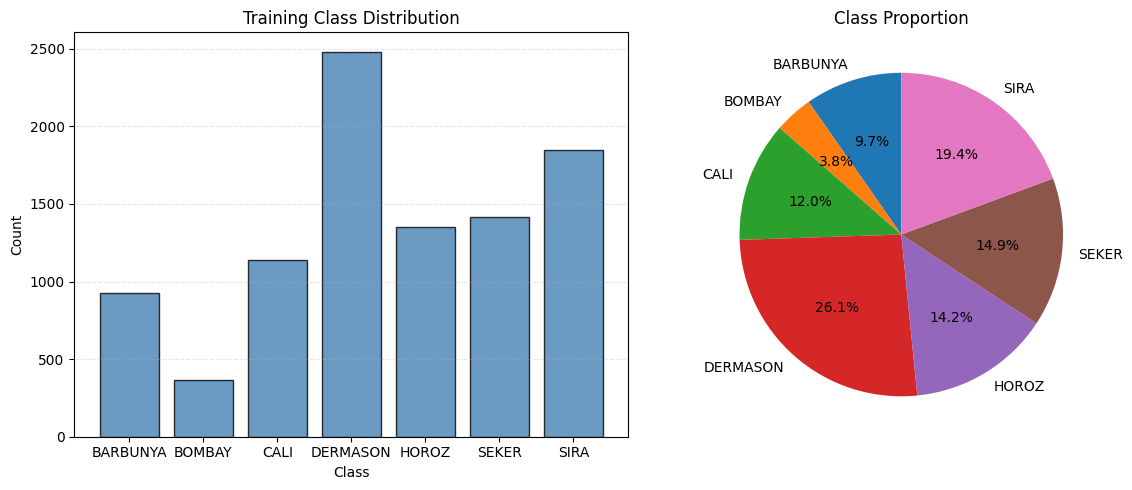

In [11]:
plot_class_distribution(
  y_train,
  class_names=target_le.classes_,
  title='Training Class Distribution',
)

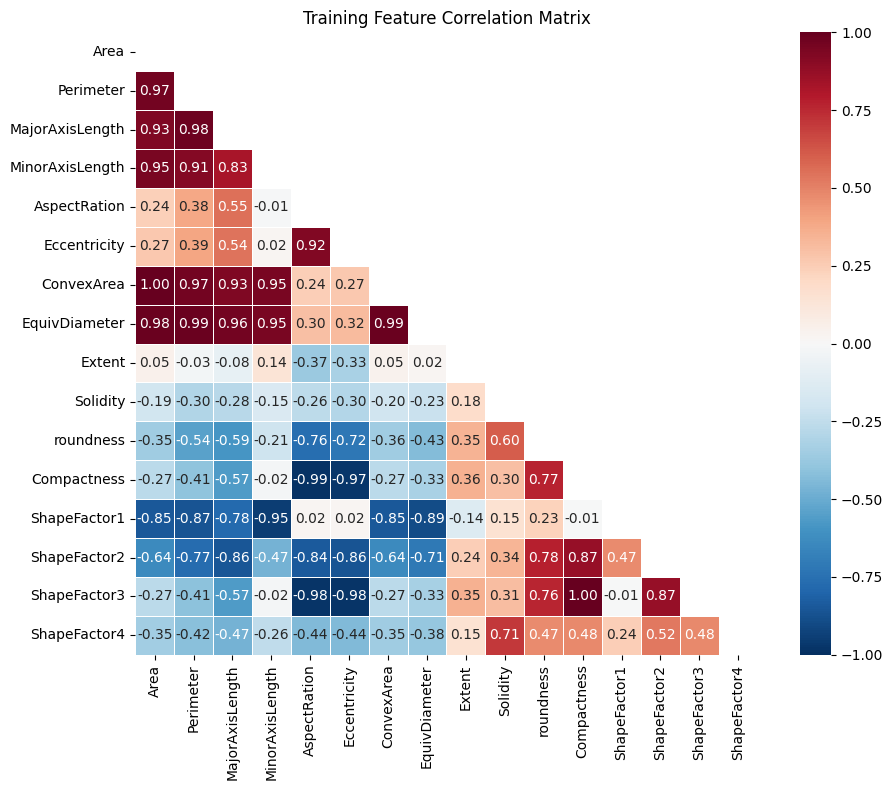

In [12]:
plot_correlation_heatmap(
  X_train,
  title='Training Feature Correlation Matrix',
)

### Trình bày trực quan kết quả EDA/mô hình ở bước trước

Cell này tiếp tục phần phân tích ngay phía trên bằng cách hiển thị thêm bảng, biểu đồ hoặc kết quả trung gian để người đọc theo dõi mạch thí nghiệm.

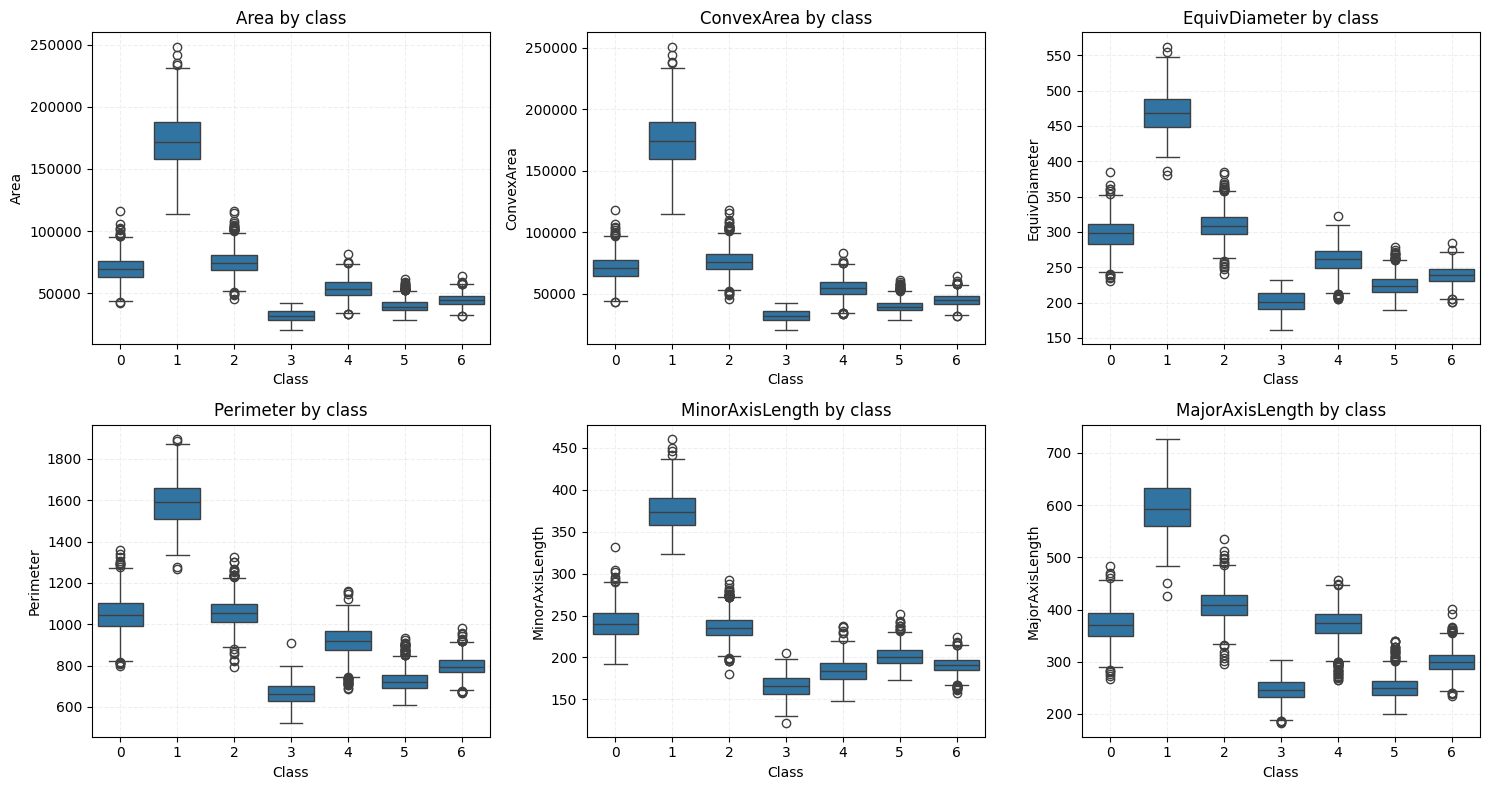

In [13]:
plot_top_feature_distributions(
  X_train,
  y_train,
  top_n=6,
)

# 3. Mô hình và huấn luyện mô hình <a id='3'></a>

In [14]:
models = {}

## 3.1 Logistic Regression (nhị phân và đa lớp)

### 3.1.1 Logistic Regression

### Cơ sở lý thuyết cho Logistic/Softmax 

Với bài toán nhị phân, Logistic Regression mô hình hóa:

$$
p(y=1\mid x)=\sigma(z),\quad z=w^Tx+b,\quad \sigma(z)=\frac{1}{1+e^{-z}}.
$$

Hàm mất mát cross-entropy trung bình:

$$
\mathcal{L}(w)= -\frac{1}{N}\sum_{n=1}^N\Big[y_n\log \hat y_n + (1-y_n)\log(1-\hat y_n)\Big].
$$

Gradient và Hessian:

$$
\nabla \mathcal{L}(w)=\frac{1}{N}X^T(\hat y-y),\qquad
H=\frac{1}{N}X^TRX,\; R=\mathrm{diag}(\hat y_n(1-\hat y_n)).
$$

Do $H\succeq 0$, bài toán là lồi, vì vậy Newton-Raphson/IRLS có thể hội tụ rất nhanh gần nghiệm tối ưu.

Với bài toán đa lớp (Softmax):

$$
y_k(x)=\frac{\exp(a_k)}{\sum_j \exp(a_j)},\quad a_k=w_k^Tx+b_k.
$$

Với 1 mẫu, Jacobian của softmax là:

$$
\frac{\partial y_k}{\partial a_j}=y_k(\delta_{kj}-y_j).
$$

Tổng quát trên toàn bộ mẫu, Hessian theo từng khối có dạng:

$$
H=\sum_{n=1}^N x_nx_n^T \otimes \left(\mathrm{Diag}(y_n)-y_ny_n^T\right),
$$

cho thấy ma trận độ cong dương bán xác định, phù hợp với tối ưu hóa bằng các phương pháp gradient/Newton.

In [15]:
binary_slice = make_binary_subset(
  X_train_scaled,
  y_train,
  X_test_scaled,
  y_test,
  binary_classes=BINARY_CLASSES,
  feature_indices=BINARY_FEATURE_INDICES,
)

binary_class_0, binary_class_1 = binary_slice.class_0, binary_slice.class_1
feat_idx_0, feat_idx_1 = binary_slice.feature_indices
X_train_bin, y_train_bin = binary_slice.X_train_bin, binary_slice.y_train_bin
X_test_bin, y_test_bin = binary_slice.X_test_bin, binary_slice.y_test_bin

logreg = build_from_config(LogisticRegression, logreg_cfg)
logreg.fit(X=X_train_bin, y=y_train_bin)
models['Logistic Regression (Binary)'] = logreg

logreg_preds = logreg.predict(X=X_test_bin)
logreg_eval = logreg.evaluate(y_pred=logreg_preds, y_true=y_test_bin)
print('Logistic Regression Binary Evaluation:', logreg_eval)

Binary subset -> classes=(0, 2), features=(0, 1), train=2066, test=591
Iteration 0: Loss 0.6931
Iteration 1000: Loss 0.6727
Iteration 2000: Loss 0.6638
Iteration 3000: Loss 0.6563
Iteration 4000: Loss 0.6496
Iteration 5000: Loss 0.6436
Iteration 6000: Loss 0.6380
Iteration 7000: Loss 0.6327
Iteration 8000: Loss 0.6278
Iteration 9000: Loss 0.6231
Iteration 10000: Loss 0.6186
Iteration 11000: Loss 0.6144
Iteration 12000: Loss 0.6103
Iteration 13000: Loss 0.6063
Iteration 14000: Loss 0.6026
Iteration 15000: Loss 0.5990
Iteration 16000: Loss 0.5955
Iteration 17000: Loss 0.5921
Iteration 18000: Loss 0.5889
Iteration 19000: Loss 0.5858
Logistic Regression Binary Evaluation: {'accuracy': 0.7461928934010152, 'precision': 0.7555519106804107, 'recall': 0.7461928934010152, 'f1-score': 0.7388632326951119, 'macro_avg': {'precision': 0.7595164943890436, 'recall': 0.7307500868156036, 'f1-score': 0.7326533812637217}, 'weighted_avg': {'precision': 0.7555519106804107, 'recall': 0.7461928934010152, 'f1-s

### 3.1.2 So sánh Gradient Descent và Newton-IRLS

Với Logistic Regression, ta có thể tối ưu bằng phương pháp bậc một như Gradient Descent hoặc phương pháp bậc hai như Newton-IRLS. Gradient Descent chỉ dùng thông tin gradient nên mỗi bước rẻ hơn nhưng thường cần nhiều vòng lặp hơn. Ngược lại, Newton-IRLS khai thác thêm Hessian để điều chỉnh hướng đi theo độ cong của hàm mục tiêu, vì thế thường hội tụ nhanh hơn trên các bài toán lồi như logistic regression.

Iteration 0: Loss 0.6931
Iteration 1000: Loss 0.6727
Iteration 2000: Loss 0.6638
Iteration 3000: Loss 0.6563
Iteration 4000: Loss 0.6496
Iteration 5000: Loss 0.6436
Iteration 6000: Loss 0.6380
Iteration 7000: Loss 0.6327
Iteration 8000: Loss 0.6278
Iteration 9000: Loss 0.6231
Iteration 10000: Loss 0.6186
Iteration 11000: Loss 0.6144
Iteration 12000: Loss 0.6103
Iteration 13000: Loss 0.6063
Iteration 14000: Loss 0.6026
Iteration 15000: Loss 0.5990
Iteration 16000: Loss 0.5955
Iteration 17000: Loss 0.5921
Iteration 18000: Loss 0.5889
Iteration 19000: Loss 0.5858
Iteration 20000: Loss 0.5828
Iteration 21000: Loss 0.5799
Iteration 22000: Loss 0.5772
Iteration 23000: Loss 0.5745
Iteration 24000: Loss 0.5719
Iteration 25000: Loss 0.5694
Iteration 26000: Loss 0.5670
Iteration 27000: Loss 0.5647
Iteration 28000: Loss 0.5625
Iteration 29000: Loss 0.5603
Iteration 30000: Loss 0.5582
Iteration 31000: Loss 0.5562
Iteration 32000: Loss 0.5542
Iteration 33000: Loss 0.5523
Iteration 34000: Loss 0.550

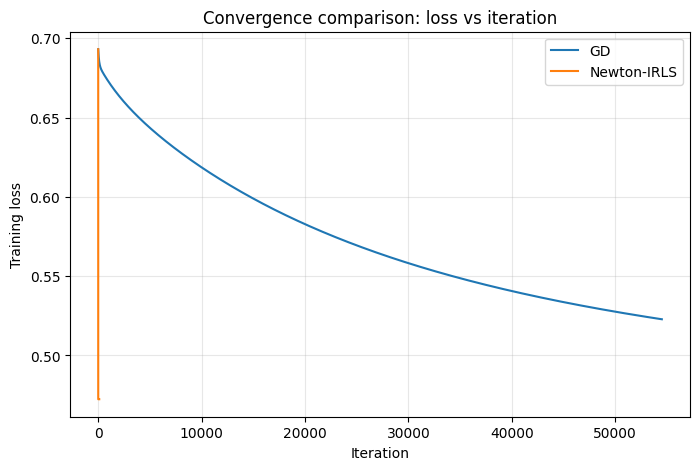

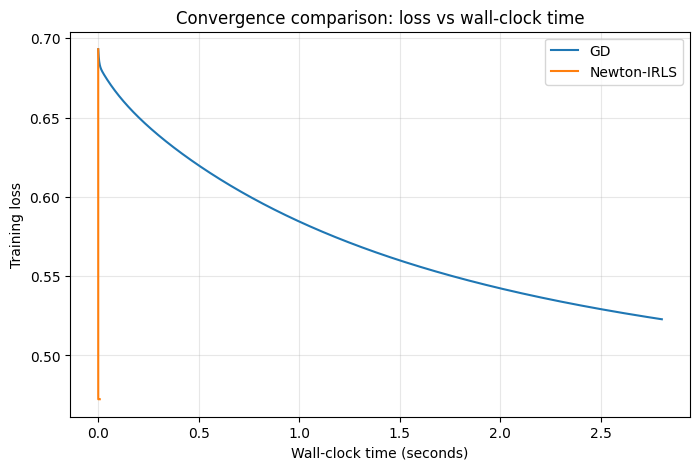

In [16]:
# Compare first-order (GD) and second-order (Newton/IRLS) optimization on the same binary task.
gd_cfg = LogisticRegressionConfig(
  learning_rate=logreg_cfg.learning_rate,
  eps=logreg_cfg.eps,
  max_iter=None,
)
nr_cfg = LogisticRegressionConfig(
  learning_rate=logreg_cfg.learning_rate,
  eps=logreg_cfg.eps,
  max_iter=None,
)

logreg_gd = build_from_config(LogisticRegression, gd_cfg)
t0 = time.perf_counter()
logreg_gd.fit(X_train_bin, y_train_bin, solver='gradient_descent')
gd_time = time.perf_counter() - t0

auto_nr = build_from_config(LogisticRegression, nr_cfg)
t0 = time.perf_counter()
auto_nr.fit(X_train_bin, y_train_bin, solver='newton_raphson')
nr_time = time.perf_counter() - t0

gd_report = classification_report(logreg_gd.predict(X_test_bin), y_test_bin)
nr_report = classification_report(auto_nr.predict(X_test_bin), y_test_bin)

print('GD vs Newton-IRLS on binary subset:')
print(f"GD -> iters={len(logreg_gd.loss_history_)}, wall_time={gd_time:.4f}s, f1={gd_report['f1-score']:.4f}")
print(f"Newton -> iters={len(auto_nr.loss_history_)}, wall_time={nr_time:.4f}s, f1={nr_report['f1-score']:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(logreg_gd.loss_history_) + 1), logreg_gd.loss_history_, label='GD')
plt.plot(np.arange(1, len(auto_nr.loss_history_) + 1), auto_nr.loss_history_, label='Newton-IRLS')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.title('Convergence comparison: loss vs iteration')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Approximate loss-vs-time by spreading total fit time across iterations.
gd_time_axis = np.linspace(0.0, gd_time, len(logreg_gd.loss_history_))
nr_time_axis = np.linspace(0.0, nr_time, len(auto_nr.loss_history_))

plt.figure(figsize=(8, 5))
plt.plot(gd_time_axis, logreg_gd.loss_history_, label='GD')
plt.plot(nr_time_axis, auto_nr.loss_history_, label='Newton-IRLS')
plt.xlabel('Wall-clock time (seconds)')
plt.ylabel('Training loss')
plt.title('Convergence comparison: loss vs wall-clock time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3.1.2 Các chiến thuật khi phân lớp đa lớp
- One-vs-Rest (OvR)
- One-vs-One (OvO)
- Softmax Regression

### Cơ sở của các chiến thuật phân lớp đa lớp

Khi bộ phân lớp gốc được xây dựng cho bài toán nhị phân, ta cần một chiến lược mở rộng để xử lý nhiều lớp. One-vs-Rest (OvR) huấn luyện $C$ mô hình nhị phân, mỗi mô hình tách một lớp khỏi phần còn lại. One-vs-One (OvO) huấn luyện $C(C-1)/2$ mô hình cho từng cặp lớp. Hai hướng này đều biến bài toán đa lớp thành tập các bài toán nhị phân nhỏ hơn.

Cell bên dưới khởi đầu phần thực nghiệm bằng cách nêu rõ ba hướng tiếp cận sẽ được so sánh: OvR, OvO và Softmax Regression.

In [17]:
print('So sánh các chiến thuật đa lớp: OvR, OvO, Softmax')

So sánh các chiến thuật đa lớp: OvR, OvO, Softmax


### One-vs-Rest: tách bài toán đa lớp thành nhiều bài toán nhị phân

Trong OvR, với mỗi lớp $k$, ta huấn luyện một bộ phân lớp để phân biệt lớp đó với tất cả các lớp còn lại. Khi dự đoán, điểm số hoặc xác suất của các mô hình này được đặt cạnh nhau và lớp có điểm cao nhất sẽ được chọn. Cách làm này đơn giản, dễ triển khai, nhưng có thể chịu ảnh hưởng bởi mất cân bằng giữa “một lớp” và “phần còn lại”.

In [18]:
ovr_preds, ovr_models = ovr_predict_with_logistic(
  X_train_scaled,
  y_train,
  X_test_scaled,
  logreg_cfg.learning_rate,
  logreg_cfg.eps,
  logreg_cfg.max_iter,
)
ovr_metrics = evaluate_multiclass_strategy(y_test, ovr_preds, 'One-vs-Rest (OvR)')

Iteration 0: Loss 0.6931
Iteration 1000: Loss 0.2200
Iteration 2000: Loss 0.1644
Iteration 3000: Loss 0.1416
Iteration 4000: Loss 0.1286
Iteration 5000: Loss 0.1199
Iteration 6000: Loss 0.1136
Iteration 7000: Loss 0.1087
Iteration 8000: Loss 0.1047
Iteration 9000: Loss 0.1013
Iteration 10000: Loss 0.0985
Iteration 11000: Loss 0.0960
Iteration 12000: Loss 0.0938
Iteration 13000: Loss 0.0919
Iteration 14000: Loss 0.0901
Iteration 15000: Loss 0.0885
Iteration 16000: Loss 0.0870
Iteration 17000: Loss 0.0857
Iteration 18000: Loss 0.0844
Iteration 19000: Loss 0.0833
Iteration 0: Loss 0.6931
Iteration 1000: Loss 0.1179
Iteration 2000: Loss 0.0633
Iteration 3000: Loss 0.0438
Iteration 4000: Loss 0.0337
Iteration 5000: Loss 0.0275
Iteration 6000: Loss 0.0234
Iteration 7000: Loss 0.0204
Iteration 8000: Loss 0.0181
Iteration 9000: Loss 0.0163
Iteration 10000: Loss 0.0148
Iteration 11000: Loss 0.0136
Iteration 12000: Loss 0.0126
Iteration 13000: Loss 0.0118
Iteration 14000: Loss 0.0110
Iteration 1

### OvO

In [19]:
ovo_preds, ovo_models = ovo_predict_with_logistic(
  X_train_scaled,
  y_train,
  X_test_scaled,
  logreg_cfg.learning_rate,
  logreg_cfg.eps,
  logreg_cfg.max_iter,
)
ovo_metrics = evaluate_multiclass_strategy(y_test, ovo_preds, 'One-vs-One (OvO)')

Iteration 0: Loss 0.6931


Iteration 1000: Loss 0.0915
Iteration 2000: Loss 0.0551
Iteration 3000: Loss 0.0405
Iteration 4000: Loss 0.0324
Iteration 5000: Loss 0.0271
Iteration 6000: Loss 0.0235
Iteration 7000: Loss 0.0207
Iteration 8000: Loss 0.0186
Iteration 9000: Loss 0.0169
Iteration 10000: Loss 0.0155
Iteration 11000: Loss 0.0143
Iteration 12000: Loss 0.0134
Iteration 13000: Loss 0.0125
Iteration 14000: Loss 0.0118
Iteration 15000: Loss 0.0111
Iteration 16000: Loss 0.0105
Iteration 17000: Loss 0.0100
Iteration 18000: Loss 0.0095
Iteration 19000: Loss 0.0091
Iteration 0: Loss 0.6931
Iteration 1000: Loss 0.2082
Iteration 2000: Loss 0.1649
Iteration 3000: Loss 0.1472
Iteration 4000: Loss 0.1373
Iteration 5000: Loss 0.1309
Iteration 6000: Loss 0.1265
Iteration 7000: Loss 0.1233
Iteration 8000: Loss 0.1208
Iteration 9000: Loss 0.1188
Iteration 10000: Loss 0.1172
Iteration 11000: Loss 0.1159
Iteration 12000: Loss 0.1148
Iteration 13000: Loss 0.1139
Iteration 14000: Loss 0.1131
Iteration 15000: Loss 0.1124
Iterati

### Softmax Regression

Khác với OvR và OvO là các chiến lược phân rã bài toán, Softmax Regression mô hình hóa trực tiếp phân phối xác suất trên toàn bộ $C$ lớp trong một mô hình duy nhất. Nhờ đó, các tham số của các lớp được học đồng thời trong một bài toán tối ưu thống nhất, và các xác suất đầu ra luôn được chuẩn hóa để tổng bằng 1.

In [20]:
softmax_model = build_from_config(SoftmaxRegression, softmax_cfg)
softmax_model.fit(X_train_scaled, y_train)

softmax_preds = softmax_model.predict(X_test_scaled)
softmax_metrics = evaluate_multiclass_strategy(
  y_test,
  softmax_preds,
  'Softmax Regression (Multinomial)',
)

models['Softmax Regression'] = softmax_model

Iteration 0: Loss 1.9459
Iteration 1000: Loss 0.5657
Iteration 2000: Loss 0.4302
Iteration 3000: Loss 0.3707
Iteration 4000: Loss 0.3371
Iteration 5000: Loss 0.3155
Iteration 6000: Loss 0.3004
Iteration 7000: Loss 0.2893
Iteration 8000: Loss 0.2806
Iteration 9000: Loss 0.2738
Iteration 10000: Loss 0.2682
Iteration 11000: Loss 0.2635
Iteration 12000: Loss 0.2596
Iteration 13000: Loss 0.2563
Iteration 14000: Loss 0.2534
Iteration 15000: Loss 0.2508
Iteration 16000: Loss 0.2486
Iteration 17000: Loss 0.2466
Iteration 18000: Loss 0.2448
Iteration 19000: Loss 0.2432
[Softmax Regression (Multinomial)] Accuracy: 0.9177
precision=0.9188, recall=0.9177, f1-score=0.9180


In [21]:
strategy_results_df = pd.DataFrame([
  ovr_metrics,
  ovo_metrics,
  softmax_metrics,
]).set_index('strategy')

print('Comparison of multiclass classification strategies:')
strategy_results_df.sort_values('accuracy', ascending=False)

Comparison of multiclass classification strategies:


,accuracy,precision,recall,f1-score
strategy,,,,
One-vs-One (OvO),0.920308,0.920608,0.920308,0.920341
Softmax Regression (Multinomial),0.917738,0.918833,0.917738,0.917966
One-vs-Rest (OvR),0.900110,0.901015,0.900110,0.900343


### 3.1.3 Laplace Approximation (Bayesian Logistic Regression)

### Laplace Approximation: xấp xỉ Bayesian quanh nghiệm MAP

Trong Logistic Regression Bayesian, thay vì chỉ lấy một bộ tham số điểm, ta còn muốn mô tả độ bất định quanh nghiệm tối ưu. Laplace Approximation thực hiện điều này bằng cách xấp xỉ hậu nghiệm của tham số bằng một phân phối Gaussian quanh nghiệm MAP; ma trận hiệp phương sai của Gaussian này được suy ra từ nghịch đảo Hessian tại điểm cực trị.

Cell bên dưới huấn luyện mô hình theo hướng Laplace để vừa dự đoán, vừa chuẩn bị cho bước trực quan hóa biên quyết định kèm mức độ bất định.

In [22]:
blr = build_from_config(LogisticRegression, logreg_cfg)
blr.fit(X=X_train_bin, y=y_train_bin, solver='laplace_approximation')

models['Bayesian Logistic Regression (Laplace)'] = blr

blr_preds = blr.predict(X=X_test_bin)
blr_eval = blr.evaluate(y_pred=blr_preds, y_true=y_test_bin)
blr_acc = blr_eval['accuracy']
print(f'Bayesian Logistic Regression (Laplace Approximation) accuracy: {blr_acc:.4f}')

Iteration 0: MAP objective 0.7153
Iteration 50: MAP objective 0.5313
Bayesian Logistic Regression (Laplace Approximation) accuracy: 0.7597


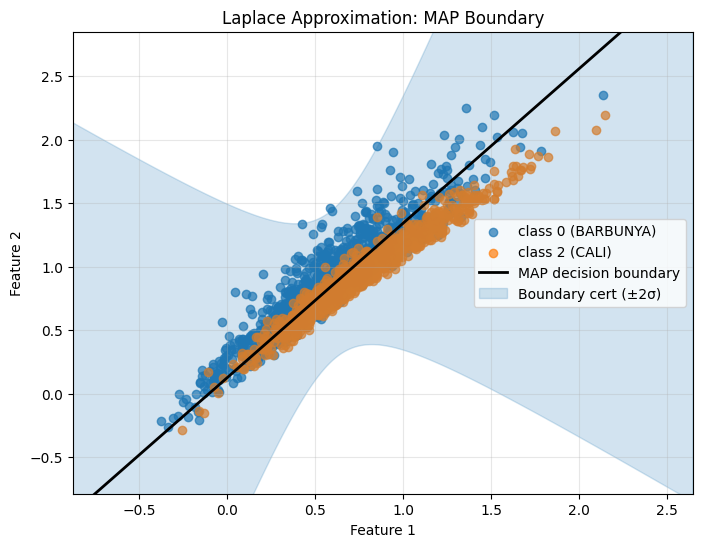

In [23]:
# 1) MAP parameters from the fitted Bayesian logistic regression
theta_map = blr.theta.copy()                    
X_aug = blr._augment(X_train_bin)            
y_binary = (y_train_bin == blr.classes_[1]).astype(float)

logits_map = X_aug @ theta_map
probs_map = 1.0 / (1.0 + np.exp(-np.clip(logits_map, -500, 500)))
W_diag = probs_map * (1.0 - probs_map)

n_samples = X_aug.shape[0]
prior_mask = blr._prior_mask(X_aug.shape[1])
reg = blr.prior_precision / n_samples

H_map = (X_aug.T * W_diag) @ X_aug / n_samples
H_map += reg * np.diag(prior_mask)
H_map += 1e-8 * np.eye(X_aug.shape[1])

posterior_cov = np.linalg.pinv(H_map)
posterior_cov = 0.5 * (posterior_cov + posterior_cov.T)
posterior_mean = theta_map

w1, w2, b = posterior_mean
if np.isclose(w2, 0.0):
    print("w2 near zero, skipping 2D plot")
else:
    x_grid = np.linspace(X_train_bin[:, 0].min() - 0.5, X_train_bin[:, 0].max() + 0.5, 400)
    y_boundary_mean = -(b + w1 * x_grid) / w2

    grads = np.column_stack([
        -x_grid / w2,
        (b + w1 * x_grid) / (w2 ** 2),
        -np.ones_like(x_grid) / w2,
    ])
    boundary_var = np.einsum('bi,ij,bj->b', grads, posterior_cov, grads)
    boundary_var = np.maximum(boundary_var, 0.0)
    boundary_std = np.sqrt(boundary_var)

    y_upper = y_boundary_mean + 2.0 * boundary_std
    y_lower = y_boundary_mean - 2.0 * boundary_std

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_train_bin[y_train_bin == blr.classes_[0], 0],
        X_train_bin[y_train_bin == blr.classes_[0], 1],
        label=f"class {blr.classes_[0]} ({target_le.classes_[blr.classes_[0]]})", alpha=0.7,
    )
    plt.scatter(
        X_train_bin[y_train_bin == blr.classes_[1], 0],
        X_train_bin[y_train_bin == blr.classes_[1], 1],
        label=f"class {blr.classes_[1]} ({target_le.classes_[blr.classes_[1]]})", alpha=0.7,
    )
    plt.plot(x_grid, y_boundary_mean, color='black', linewidth=2, label='MAP decision boundary')
    plt.fill_between(x_grid, y_lower, y_upper, color='tab:blue', alpha=0.2, label='Boundary cert (±2σ)')
    plt.xlim(x_grid.min(), x_grid.max())
    plt.ylim(X_train_bin[:, 1].min() - 0.5, X_train_bin[:, 1].max() + 0.5)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Laplace Approximation: MAP Boundary')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


## 3.2 Linear Discriminant Analysis - LDA và QDA

### 3.2.1 LDA và QDA

Tóm tắt lý thuyết cốt lõi:

- **LDA (Linear Discriminant Analysis)** giả thiết các lớp Gaussian có **cùng ma trận hiệp phương sai** $\Sigma$, nên hàm phân biệt theo Bayes có dạng tuyến tính theo $x$.
- **QDA (Quadratic Discriminant Analysis)** cho phép mỗi lớp có $\Sigma_k$ riêng, vì vậy biên quyết định có dạng bậc hai (phi tuyến trong không gian đầu vào).
- Đánh đổi chính: LDA có ít tham số hơn nên thường ổn định hơn khi dữ liệu ít hoặc chiều lớn; QDA linh hoạt hơn nhưng dễ overfit nếu số mẫu mỗi lớp không đủ lớn.

Về mặt ước lượng:
- LDA: ước lượng $\mu_k$, prior $\pi_k$, và một $\Sigma$ dùng chung.
- QDA: ước lượng $\mu_k$, $\pi_k$, và $\Sigma_k$ cho từng lớp.


#### LDA

In [24]:
lda = build_from_config(LDA, lda_cfg)
lda.fit(X=X_train_scaled, y=y_train)

models['LDA'] = lda

lda_preds = lda.predict(X=X_test_scaled)
lda_eval = lda.evaluate(y_pred=lda_preds, y_true=y_test)
lda_acc = lda_eval['accuracy']
print(f'LDA accuracy: {lda_acc:.4f}')

LDA accuracy: 0.9005


#### QDA

In [25]:
qda = build_from_config(QDA, qda_cfg)
qda.fit(X=X_train_scaled, y=y_train)

models['QDA'] = qda

qda_preds = qda.predict(X=X_test_scaled)
qda_eval = qda.evaluate(y_pred=qda_preds, y_true=y_test)
qda_acc = qda_eval['accuracy']
print(f'QDA accuracy: {qda_acc:.4f}')

QDA accuracy: 0.9071


### 3.2.2 Fisher ratio feature ranking

Với mỗi đặc trưng $x_j$, ta xem hướng chiếu chỉ chọn đúng tọa độ đó, khi đó tiêu chuẩn Fisher trở thành

$$
J(w_j) = J_j = \frac{\sum_{c=1}^{C} n_c (\mu_{c,j} - \mu_j)^2}{\sum_{c=1}^{C} n_c \, \sigma_{c,j}^2}
$$

Trong đó $n_c$ là số mẫu huấn luyện của lớp $c$, $\mu_{c,j}$ và $\sigma_{c,j}^2$ lần lượt là trung bình và phương sai của đặc trưng $j$ trong lớp $c$, còn $\mu_j$ là trung bình toàn cục của đặc trưng $j$. Giá trị $J_j$ càng lớn thì đặc trưng đó càng phân tách lớp tốt so với độ phân tán trong từng lớp.

### Fisher ratio để xếp hạng đặc trưng

Fisher ratio đo mức độ tách biệt giữa các lớp thông qua tỷ lệ giữa phương sai liên lớp và phương sai nội lớp. Một đặc trưng có Fisher ratio cao thường mang nhiều thông tin phân lớp hơn, vì trung bình của các lớp khác nhau đủ xa trong khi độ phân tán trong từng lớp không quá lớn.

In [26]:
# Fisher ratio cho từng đặc trưng (bài toán đa lớp)
fisher_df = fisher_ratio_ranking(
  X_train_df=X_train,
  X_train_scaled=X_train_scaled,
  y_train=y_train,
)

print('Bảng xếp hạng Fisher ratio (càng cao càng tốt):')
fisher_df

Bảng xếp hạng Fisher ratio (càng cao càng tốt):


,feature,fisher_ratio
0,Area,13.038658
1,ConvexArea,13.023622
2,EquivDiameter,11.314876
3,Perimeter,10.791494
4,MinorAxisLength,10.005911
5,MajorAxisLength,9.528009
6,ShapeFactor1,5.375710
7,ShapeFactor2,5.322083
8,AspectRation,4.461345
9,Compactness,4.374068


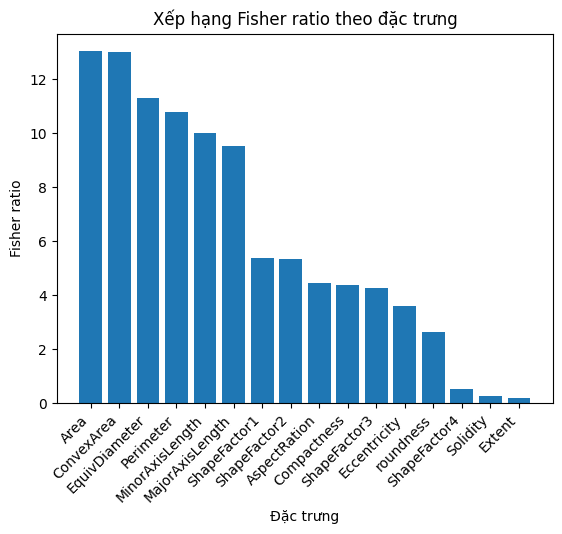

In [27]:
plt.bar(fisher_df['feature'], fisher_df['fisher_ratio'])
plt.xlabel('Đặc trưng')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fisher ratio')
plt.title('Xếp hạng Fisher ratio theo đặc trưng')

plt.show()

### 3.2.3 Vẽ quy chiếu LDA xuống 2D và biểu diễn đường quyết định

### Chiếu dữ liệu xuống không gian LDA 2 chiều

LDA có thể được nhìn như một phép biến đổi tuyến tính nhằm tối đa hóa khả năng tách lớp sau chiếu. Các trục mới được chọn sao cho khoảng cách giữa trung bình các lớp lớn, trong khi độ phân tán nội lớp vẫn được giữ nhỏ tương đối.

LDA 2D projection captures about 0.7599 of the discriminative eigenvalue mass.


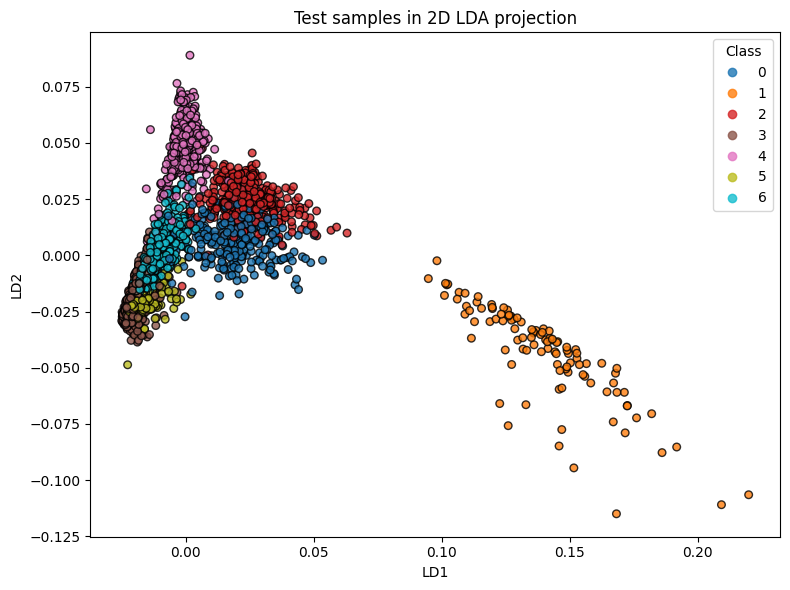

In [28]:
# Project the data to 2D using the LDA model projection methods
lda_projection = build_from_config(LDA, lda_cfg)
X_train_lda_2d = lda_projection.fit_transform(X_train_scaled, y_train, n_components=2)
X_test_lda_2d = lda_projection.transform(X_test_scaled, n_components=2)
explained_ratio = lda_projection.explained_discriminative_ratio(n_components=2)
print(f'LDA 2D projection captures about {explained_ratio.sum():.4f} of the discriminative eigenvalue mass.')

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
  X_test_lda_2d[:, 0],
  X_test_lda_2d[:, 1],
  c=y_test,
  cmap='tab10',
  alpha=0.8,
  edgecolor='k',
  s=30,
)
plt.title('Test samples in 2D LDA projection')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend(*scatter.legend_elements(), title='Class', loc='best')
plt.tight_layout()
plt.show()

LDA accuracy on 2D projected space: 0.7297


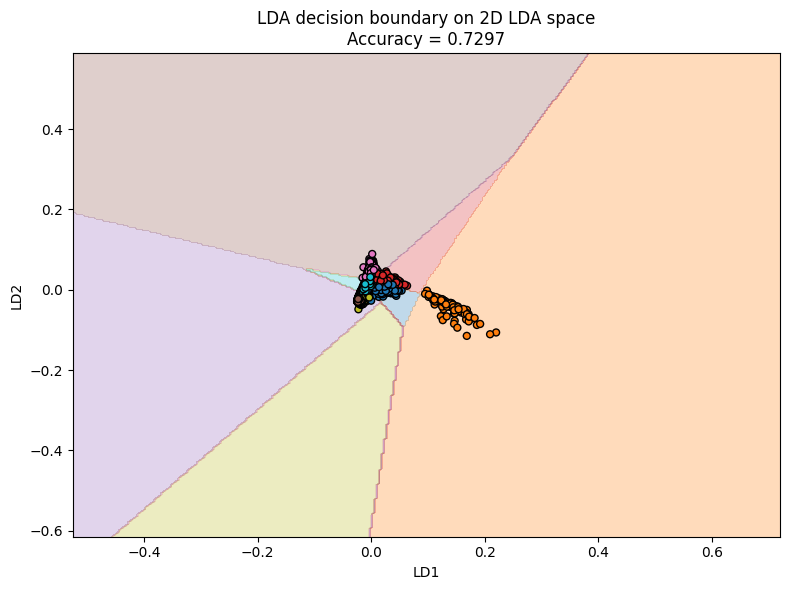

In [29]:
# Fit LDA on the 2D projected space and draw its decision boundary
lda_2d = build_from_config(LDA, lda_cfg)
lda_2d.fit(X_train_lda_2d, y_train)
lda_2d_preds_2d = lda_2d.predict(X_test_lda_2d)
lda_eval_2d = lda_2d.evaluate(lda_2d_preds_2d, y_test)
lda_acc_2d = lda_eval_2d['accuracy']
print(f'LDA accuracy on 2D projected space: {lda_acc_2d:.4f}')

all_points = np.vstack([X_train_lda_2d, X_test_lda_2d])
x_min, x_max = all_points[:, 0].min() - 0.5, all_points[:, 0].max() + 0.5
y_min, y_max = all_points[:, 1].min() - 0.5, all_points[:, 1].max() + 0.5
xx, yy = np.meshgrid(
  np.linspace(x_min, x_max, 300),
  np.linspace(y_min, y_max, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
lda_grid = lda_2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, lda_grid, alpha=0.28, cmap='tab10')
plt.scatter(
  X_test_lda_2d[:, 0],
  X_test_lda_2d[:, 1],
  c=y_test,
  cmap='tab10',
  edgecolor='k',
  s=25,
)
plt.title(f'LDA decision boundary on 2D LDA space\nAccuracy = {lda_acc_2d:.4f}')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.tight_layout()
plt.show()

### 3.2.4 Khi nào LDA tốt hơn QDA và ngược lại

**Khi LDA thường tốt hơn**

- LDA giả định mọi lớp dùng chung một ma trận hiệp phương sai, nên số tham số cần ước lượng ít hơn QDA. Điều này thường làm LDA ổn định hơn khi dữ liệu không quá lớn hoặc số chiều đặc trưng tương đối cao.
- Nếu các lớp chủ yếu khác nhau ở trung bình, trong khi độ phân tán và hướng phân bố tương tự nhau, biên tuyến tính của LDA thường đủ tốt và tổng quát hóa tốt hơn.
- LDA cũng ít bị quá khớp hơn khi một số lớp có ít mẫu huấn luyện.

**Khi QDA thường tốt hơn**

- QDA cho phép mỗi lớp có ma trận hiệp phương sai riêng, nên phù hợp hơn khi các lớp có độ phân tán, hình dạng hoặc hướng khác nhau rõ rệt.
- Nếu biên phân lớp là phi tuyến, QDA có thể mô hình hóa tốt hơn do bề mặt quyết định là bậc hai.
- Khi mỗi lớp có đủ dữ liệu để ước lượng hiệp phương sai tin cậy, QDA có thể tận dụng độ linh hoạt bổ sung để vượt LDA.

### Gaussian Naive Bayes và giả thiết độc lập có điều kiện

Gaussian Naive Bayes giả sử rằng, khi biết lớp, các đặc trưng liên tục độc lập có điều kiện với nhau và từng đặc trưng có phân phối Gaussian. So với LDA/QDA, mô hình này đơn giản hơn vì không cần ước lượng đầy đủ hiệp phương sai giữa các biến, nhưng đánh đổi bằng giả thiết mạnh hơn.

### 3.2.5 Gaussian Naive Bayes (giả thiết độc lập) với LDA

### 3.2.6 Thực nghiệm – Khi nào GNB thực tế tốt hơn LDA dù giả thiết kém chặt hơn?
- **LDA** giả thiết mọi lớp dùng chung một ma trận hiệp phương sai đầy đủ $\Sigma$ (kích thước $d \times d$), cần ước lượng $\mathcal{O}(d^2)$ tham số.
- **GNB** giả thiết các đặc trưng **độc lập có điều kiện** theo lớp, mỗi lớp chỉ cần $d$ phương sai riêng → chỉ $\mathcal{O}(Kd)$ tham số.
- GNB có giả thiết **mạnh hơn** (strict hơn), nhưng bù lại có **ít tham số hơn nhiều**. Đánh đổi bias–variance này cho phép GNB tốt hơn trong một số tình huống thực tế.

**Ba tình huống thực nghiệm**

| Scenario | Đặc điểm dữ liệu | Dự đoán |
|---|---|---|
| A | Đặc trưng độc lập có điều kiện, phương sai khác nhau giữa các lớp | GNB ≥ LDA |
| B | Tỉ lệ $d/n$ lớn (50 chiều, $n$ thay đổi từ 30 → 2000) | GNB thắng ở $n$ nhỏ |
| C | Đặc trưng có tương quan mạnh, hiệp phương sai dùng chung | LDA > GNB |

In [30]:
from sklearn.model_selection import train_test_split as sk_split

rng = np.random.default_rng(SEED)

def make_synthetic(scenario: str, n_samples: int = 600, n_features: int = 2, seed: int = SEED):
    """Generate (X_train, X_test, y_train, y_test) for a named scenario."""
    rng_local = np.random.default_rng(seed)
    n_per_class = n_samples // 2

    if scenario == "A":
        # Independent features, very different per-class variances (diagonal != shared)
        mu0 = np.zeros(n_features)
        mu1 = np.full(n_features, 2.0)
        # Class 0: large var on even dims, small on odd
        var0 = np.where(np.arange(n_features) % 2 == 0, 4.0, 0.3)
        var1 = np.where(np.arange(n_features) % 2 == 0, 0.3, 4.0)
        X0 = rng_local.normal(mu0, np.sqrt(var0), size=(n_per_class, n_features))
        X1 = rng_local.normal(mu1, np.sqrt(var1), size=(n_per_class, n_features))

    elif scenario == "B":
        mu0 = np.zeros(n_features)
        mu1 = np.zeros(n_features)
        mu1[:5] = 1.0
        var0 = rng_local.uniform(0.5, 3.0, size=n_features)
        var1 = rng_local.uniform(0.5, 3.0, size=n_features)
        X0 = rng_local.normal(mu0, np.sqrt(var0), size=(n_per_class, n_features))
        X1 = rng_local.normal(mu1, np.sqrt(var1), size=(n_per_class, n_features))

    elif scenario == "C":
        mu0 = np.zeros(n_features)
        mu1 = np.full(n_features, 1.5)
        # Shared covariance with strong off-diagonal correlations
        base = rng_local.standard_normal((n_features, n_features))
        cov_shared = base @ base.T / n_features + 0.3 * np.eye(n_features)
        X0 = rng_local.multivariate_normal(mu0, cov_shared, size=n_per_class)
        X1 = rng_local.multivariate_normal(mu1, cov_shared, size=n_per_class)
    else:
        raise ValueError(f"Unknown scenario: {scenario}")

    X = np.vstack([X0, X1])
    y = np.array([0] * n_per_class + [1] * n_per_class)
    return sk_split(X, y, test_size=0.3, random_state=seed, stratify=y)

print("Synthetic data helpers ready.")

Synthetic data helpers ready.


#### Scenario A: Đặc trưng độc lập, phương sai khác nhau giữa lớp → GNB có lợi

GNB ước lượng đúng cấu trúc diagonal per-class; LDA buộc chia sẻ chung Σ nên bị misspecified.

[Scenario A] GNB accuracy: 0.9000  |  LDA accuracy: 0.8222
  → GNB wins


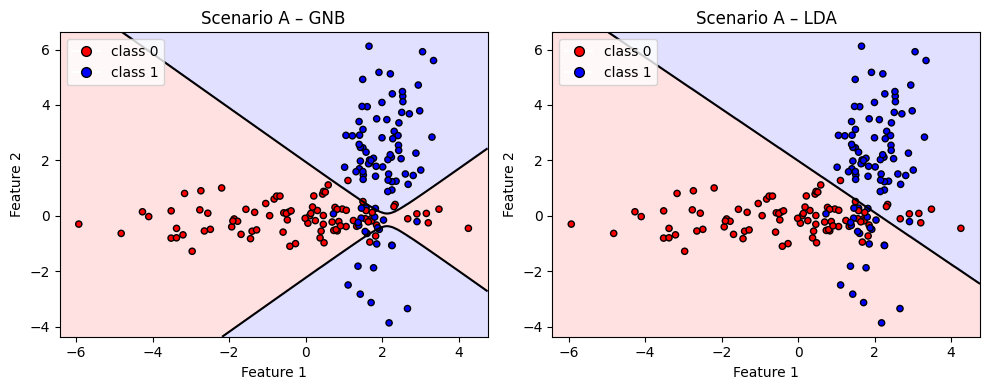

In [31]:
X_tr_a, X_te_a, y_tr_a, y_te_a = make_synthetic("A", n_samples=600, n_features=2)

gnb_a = GaussianNaiveBayes(reg=1e-6)
gnb_a.fit(X_tr_a, y_tr_a)
gnb_pred_a = gnb_a.predict(X_te_a)

lda_a = LDA(reg=1e-6)
lda_a.fit(X_tr_a, y_tr_a)
lda_pred_a = lda_a.predict(X_te_a)

gnb_acc_a = float(np.mean(gnb_pred_a == y_te_a))
lda_acc_a = float(np.mean(lda_pred_a == y_te_a))
print(f"[Scenario A] GNB accuracy: {gnb_acc_a:.4f}  |  LDA accuracy: {lda_acc_a:.4f}")
print(f"  → {'GNB wins' if gnb_acc_a > lda_acc_a else 'LDA wins' if lda_acc_a > gnb_acc_a else 'Tie'}")

# Decision boundaries
from utils import plot_2d_decision_boundary
plot_2d_decision_boundary(
    {"GNB": gnb_a, "LDA": lda_a},
    X_te_a, y_te_a,
    title_prefix="Scenario A –",
)

#### Scenario C: Đặc trưng tương quan mạnh, hiệp phương sai chung → LDA có lợi

LDA khớp đúng mô hình sinh; GNB bỏ qua tương quan nên mất thông tin phân biệt.

[Scenario C] GNB accuracy: 0.9000  |  LDA accuracy: 0.9222
  → LDA wins


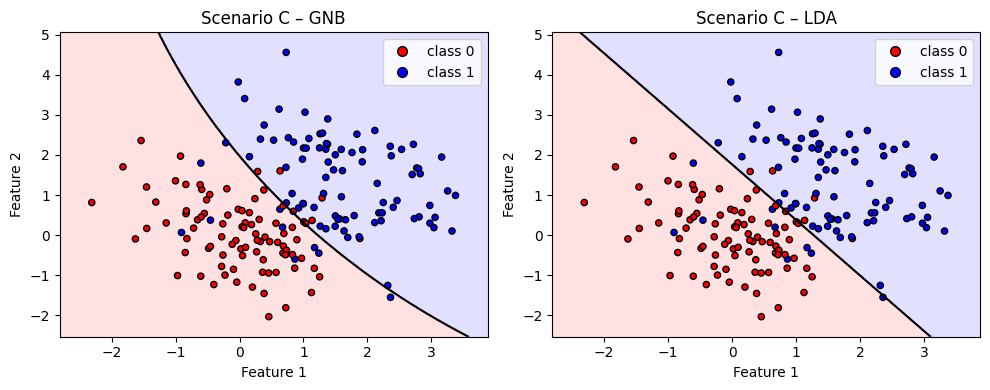

In [32]:
X_tr_c, X_te_c, y_tr_c, y_te_c = make_synthetic("C", n_samples=600, n_features=2)

gnb_c = GaussianNaiveBayes(reg=1e-6)
gnb_c.fit(X_tr_c, y_tr_c)
gnb_pred_c = gnb_c.predict(X_te_c)

lda_c = LDA(reg=1e-6)
lda_c.fit(X_tr_c, y_tr_c)
lda_pred_c = lda_c.predict(X_te_c)

gnb_acc_c = float(np.mean(gnb_pred_c == y_te_c))
lda_acc_c = float(np.mean(lda_pred_c == y_te_c))
print(f"[Scenario C] GNB accuracy: {gnb_acc_c:.4f}  |  LDA accuracy: {lda_acc_c:.4f}")
print(f"  → {'GNB wins' if gnb_acc_c > lda_acc_c else 'LDA wins' if lda_acc_c > gnb_acc_c else 'Tie'}")

plot_2d_decision_boundary(
    {"GNB": gnb_c, "LDA": lda_c},
    X_te_c, y_te_c,
    title_prefix="Scenario C –",
)

#### Scenario B: Learning curve – d=50, n thay đổi

Khi $d$ lớn mà $n$ nhỏ, LDA cần ước lượng ma trận hiệp phương sai $50 \times 50$ (1275 tham số) trong khi GNB chỉ cần 100 phương sai. Số tham số ít hơn giúp GNB ổn định hơn ở vùng dữ liệu hạn chế.

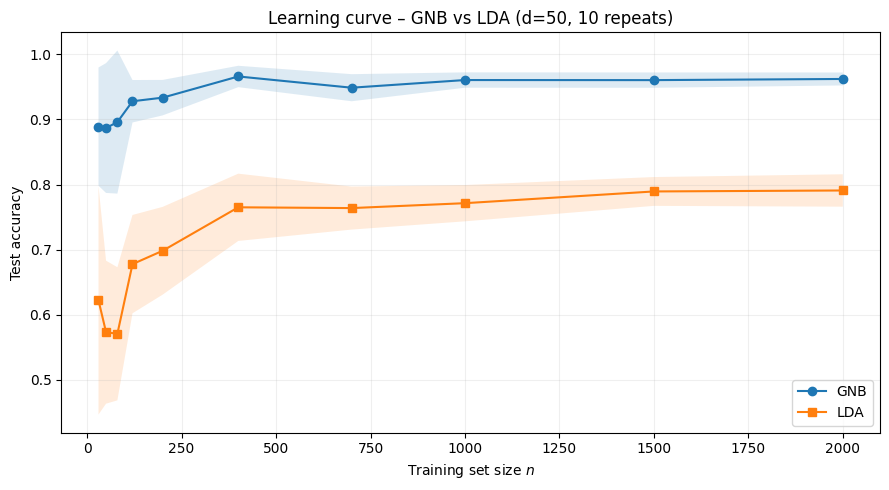

GNB dominates across all tested sample sizes.


In [33]:
d_fixed = 50
sample_sizes = [30, 50, 80, 120, 200, 400, 700, 1000, 1500, 2000]
n_repeats = 10

gnb_means, lda_means = [], []
gnb_stds, lda_stds = [], []

for n in sample_sizes:
    gnb_accs, lda_accs = [], []
    for rep in range(n_repeats):
        seed = SEED + rep
        X_tr_b, X_te_b, y_tr_b, y_te_b = make_synthetic(
            "B", n_samples=n, n_features=d_fixed, seed=seed
        )
        g = GaussianNaiveBayes(reg=1e-6)
        g.fit(X_tr_b, y_tr_b)
        gnb_accs.append(float(np.mean(g.predict(X_te_b) == y_te_b)))

        l = LDA(reg=1e-4)
        l.fit(X_tr_b, y_tr_b)
        lda_accs.append(float(np.mean(l.predict(X_te_b) == y_te_b)))

    gnb_means.append(np.mean(gnb_accs))
    gnb_stds.append(np.std(gnb_accs, ddof=1))
    lda_means.append(np.mean(lda_accs))
    lda_stds.append(np.std(lda_accs, ddof=1))

gnb_means = np.array(gnb_means)
lda_means = np.array(lda_means)
gnb_stds = np.array(gnb_stds)
lda_stds = np.array(lda_stds)

plt.figure(figsize=(9, 5))
plt.plot(sample_sizes, gnb_means, "o-", label="GNB")
plt.fill_between(sample_sizes, gnb_means - gnb_stds, gnb_means + gnb_stds, alpha=0.15)
plt.plot(sample_sizes, lda_means, "s-", label="LDA")
plt.fill_between(sample_sizes, lda_means - lda_stds, lda_means + lda_stds, alpha=0.15)
plt.xlabel("Training set size $n$")
plt.ylabel("Test accuracy")
plt.title(f"Learning curve – GNB vs LDA (d={d_fixed}, {n_repeats} repeats)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

cross_idx = None
for i in range(len(sample_sizes) - 1):
    if gnb_means[i] > lda_means[i] and gnb_means[i + 1] <= lda_means[i + 1]:
        cross_idx = i
        break
if cross_idx is not None:
    print(
        f"GNB dominates until n ≈ {sample_sizes[cross_idx]}–{sample_sizes[cross_idx+1]}, "
        f"then LDA takes over."
    )
else:
    better = "GNB" if gnb_means[-1] > lda_means[-1] else "LDA"
    print(f"{better} dominates across all tested sample sizes.")

#### Tổng hợp kết quả

In [34]:
summary_rows = [
    ("A - indep, heterogeneous var", gnb_acc_a, lda_acc_a),
    (f"B - d={d_fixed}, n={sample_sizes[0]} (smallest)", gnb_means[0], lda_means[0]),
    (f"B - d={d_fixed}, n={sample_sizes[-1]} (largest)", gnb_means[-1], lda_means[-1]),
    ("C - correlated, shared cov", gnb_acc_c, lda_acc_c),
]

print(f"{'Scenario':<40}  {'GNB':>8}  {'LDA':>8}  Winner")
print("-" * 70)
for desc, g, l in summary_rows:
    better = "GNB" if g > l else ("LDA" if l > g else "Tie")
    print(f"{desc:<40} {g:>8.4f} {l:>8.4f} {better}")

Scenario                                       GNB       LDA  Winner
----------------------------------------------------------------------
A - indep, heterogeneous var               0.9000   0.8222 GNB
B - d=50, n=30 (smallest)                  0.8889   0.6222 GNB
B - d=50, n=2000 (largest)                 0.9620   0.7908 GNB
C - correlated, shared cov                 0.9000   0.9222 LDA


#### Kết luận thực nghiệm GNB vs LDA

**Khi nào GNB tốt hơn?**

1. **Đặc trưng (gần) độc lập có điều kiện và phương sai khác nhau giữa các lớp** (Scenario A): LDA buộc chia sẻ chung $\Sigma$ nên trung bình hóa phương sai giữa hai lớp, làm biên quyết định lệch. GNB ước lượng đúng cấu trúc diagonal per-class và phân biệt tốt hơn.

2. **Dữ liệu ít, chiều cao** (Scenario B, $n$ nhỏ): GNB chỉ cần $\mathcal{O}(Kd)$ tham số so với $\mathcal{O}(d^2)$ của LDA. Khi $n$ quá nhỏ để ước lượng đáng tin cậy $d(d+1)/2$ phần tử hiệp phương sai, variance của LDA tăng mạnh và accuracy giảm. GNB có bias cao hơn nhưng variance thấp hơn rất nhiều → tổng lỗi nhỏ hơn.

**Khi nào LDA tốt hơn?**

3. **Đặc trưng có tương quan mạnh và hiệp phương sai chia sẻ đúng** (Scenario C): LDA khớp đúng mô hình sinh nên khai thác toàn bộ cấu trúc liên hợp giữa biến. GNB coi mỗi biến riêng biệt nên mất thông tin phân biệt nằm ở hướng tương quan chéo.

4. **Dữ liệu đủ lớn** (Scenario B, $n$ lớn): Khi $n \gg d^2$, LDA ước lượng hiệp phương sai ổn định và tận dụng được toàn bộ cấu trúc tương quan mà GNB bỏ qua.

**Tóm tắt**: GNB nên được ưu tiên khi đặc trưng tương đối độc lập, phương sai giữa các lớp khác nhau rõ, hoặc dữ liệu hạn chế so với số chiều. LDA nên được ưu tiên khi có đủ mẫu và tương quan giữa các đặc trưng mang thông tin phân biệt lớp.

In [35]:
gnb = build_from_config(GaussianNaiveBayes, gnb_cfg)
gnb.fit(X=X_train_scaled, y=y_train)
gnb_preds = gnb.predict(X=X_test_scaled)
gnb_eval = gnb.evaluate(gnb_preds, y_test)
gnb_acc = gnb_eval['accuracy']
print(f'Gaussian Naive Bayes accuracy: {gnb_acc:.4f}')

models['Gaussian Naive Bayes'] = gnb

Gaussian Naive Bayes accuracy: 0.8990


## 3.3 Perceptron và Logistic Regression có Regularization

Khung lý thuyết ngắn:

- **Perceptron** cập nhật trọng số trên các điểm phân loại sai, phù hợp với mục tiêu tìm siêu phẳng tách tuyến tính.
- Định lý hội tụ Perceptron: nếu dữ liệu tách tuyến tính, thuật toán hội tụ sau hữu hạn bước; nếu không tách tuyến tính, loss dao động và không thể về 0 hoàn toàn.
- **Logistic Regression + regularization** dùng cross-entropy kèm penalty để kiểm soát độ phức tạp mô hình.

Vai trò của regularization:
- **L1**: tạo nghiệm thưa (sparse), hỗ trợ chọn đặc trưng.
- **L2**: làm trơn nghiệm, giảm phương sai, thường ổn định hơn khi đặc trưng tương quan cao.
- **Class-weighted loss**: tăng trọng số lớp thiểu số để giảm thiên lệch trên dữ liệu mất cân bằng.


### 3.3.1 Perceptron trên bài toán nhị phân


In [36]:
perceptron_clf = build_from_config(Perceptron, perceptron_cfg)
perceptron_clf.fit(X_train_bin, y_train_bin)

print('Perceptron Report on Binary Dry Bean Subset:')
print(classification_report(perceptron_clf.predict(X_test_bin), y_test_bin))

models['Perceptron (Binary)'] = perceptron_clf

Perceptron Report on Binary Dry Bean Subset:
{'accuracy': 0.7597292724196277, 'precision': 0.7632289052930691, 'recall': 0.7597292724196277, 'f1-score': 0.7557718218674226}


Perceptron on toy datasets:
Linearly separable -> epochs=2, accuracy=1.0000
XOR-like (non-separable) -> epochs=20000, accuracy=0.5125


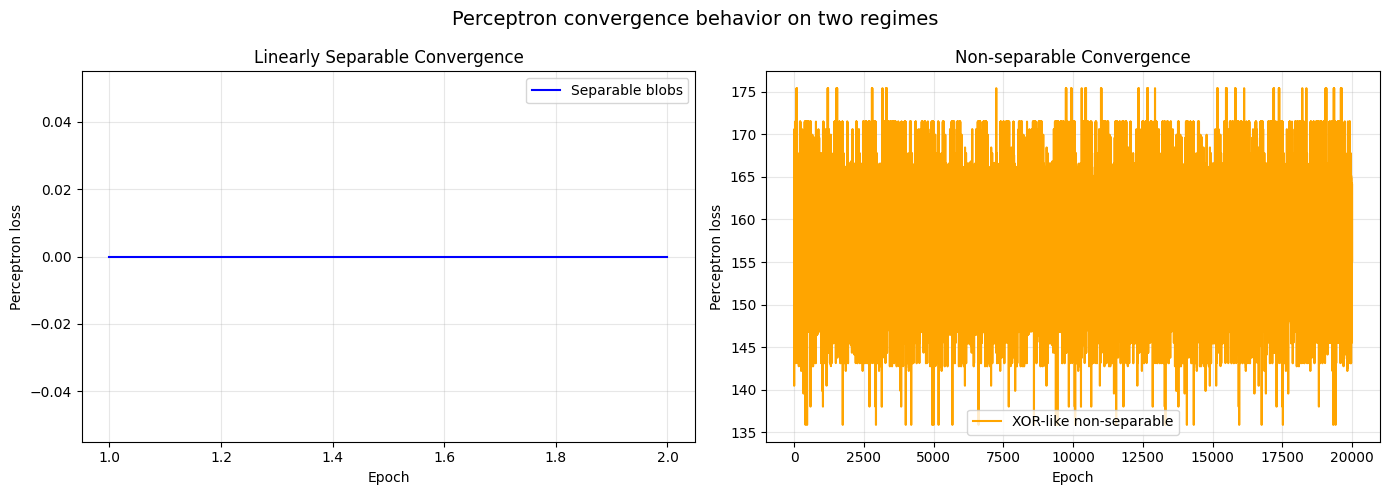

In [37]:
# Perceptron convergence behavior on linearly separable vs non-separable toy datasets.
toy_results = run_perceptron_toy_convergence(
  seed=SEED,
  n_toy=240,
  learning_rate=perceptron_cfg.learning_rate,
  max_iter=perceptron_cfg.max_iter,
)

print('Perceptron on toy datasets:')
print(
  f"Linearly separable -> epochs={toy_results['sep_epochs']}, "
  f"accuracy={toy_results['sep_accuracy']:.4f}"
)
print(
  f"XOR-like (non-separable) -> epochs={toy_results['xor_epochs']}, "
  f"accuracy={toy_results['xor_accuracy']:.4f}"
)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# --- Đồ thị 1: Dữ liệu phân tách tuyến tính (Separable) ---
axes[0].plot(
    np.arange(1, len(toy_results['sep_loss_history']) + 1),
    toy_results['sep_loss_history'],
    label='Separable blobs',
    color='blue'
)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Perceptron loss')
axes[0].set_title('Linearly Separable Convergence')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Đồ thị 2: Dữ liệu không phân tách (XOR-like) ---
axes[1].plot(
    np.arange(1, len(toy_results['xor_loss_history']) + 1),
    toy_results['xor_loss_history'],
    label='XOR-like non-separable',
    color='orange'
)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perceptron loss')
axes[1].set_title('Non-separable Convergence')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Tiêu đề chung cho cả 2 đồ thị
fig.suptitle('Perceptron convergence behavior on two regimes', fontsize=14)
plt.tight_layout()
plt.show()

### 3.3.3 Logistic Regression có Regularization

**(1) L1/L2 regularization, so sánh sparsity và hiệu năng**
- Huấn luyện các biến thể `L1`, `L2`, `Elastic Net`.
- So sánh `accuracy`, `precision`, `recall`, `f1-score` và `sparsity_ratio`.


**(2) Chọn `lambda` bằng stratified k-fold CV (`k = 5`)**
- Dùng `stratified` để giữ tỷ lệ lớp trong mỗi fold.
- Chọn `best_l1_lambda` và `best_l2_lambda` trước khi train mô hình cuối.


**(3) Class-weighted loss để xử lý mất cân bằng lớp**
- Cài đặt `class_weight='balanced'` cho bản `L2 (class-weighted)`.
- Ý tưởng: trọng số lớp `c_k` tỉ lệ nghịch với số mẫu lớp `N_k` (xấp xỉ `c_k ∝ N / N_k`).


In [38]:
from IPython.display import display

# (1) Tune lambda for L1/L2 using stratified 5-fold CV.
lambda_grid = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

tuning_df, best_lambdas = tune_logistic_regularization(
  X_train_bin,
  y_train_bin,
  base_kwargs={
    'learning_rate': logreg_cfg.learning_rate,
    'eps': logreg_cfg.eps,
    'max_iter': logreg_cfg.max_iter,
  },
  lambda_grid=lambda_grid,
  solvers=('l1', 'l2'),
  k=KFOLD_SPLITS,
  random_state=SEED,
)

print('Stratified 5-fold CV for lambda selection (binary task):')
display(tuning_df.sort_values(['penalty', 'cv_f1_mean'], ascending=[True, False]))

best_l1_lambda = best_lambdas['l1']
best_l2_lambda = best_lambdas['l2']
print(f"Best lambda (L1) = {best_l1_lambda}")
print(f"Best lambda (L2) = {best_l2_lambda}")

Iteration 0 (L1): Loss 0.6931
Iteration 1000 (L1): Loss 0.6732
Iteration 2000 (L1): Loss 0.6646
Iteration 3000 (L1): Loss 0.6572
Iteration 4000 (L1): Loss 0.6506
Iteration 5000 (L1): Loss 0.6446
Iteration 6000 (L1): Loss 0.6391
Iteration 7000 (L1): Loss 0.6339
Iteration 8000 (L1): Loss 0.6290
Iteration 9000 (L1): Loss 0.6244
Iteration 10000 (L1): Loss 0.6200
Iteration 11000 (L1): Loss 0.6158
Iteration 12000 (L1): Loss 0.6117
Iteration 13000 (L1): Loss 0.6078
Iteration 14000 (L1): Loss 0.6041
Iteration 15000 (L1): Loss 0.6005
Iteration 16000 (L1): Loss 0.5971
Iteration 17000 (L1): Loss 0.5938
Iteration 18000 (L1): Loss 0.5906
Iteration 19000 (L1): Loss 0.5876
Iteration 0 (L1): Loss 0.6931
Iteration 1000 (L1): Loss 0.6742
Iteration 2000 (L1): Loss 0.6658
Iteration 3000 (L1): Loss 0.6585
Iteration 4000 (L1): Loss 0.6519
Iteration 5000 (L1): Loss 0.6458
Iteration 6000 (L1): Loss 0.6402
Iteration 7000 (L1): Loss 0.6349
Iteration 8000 (L1): Loss 0.6298
Iteration 9000 (L1): Loss 0.6250
Iterat

,penalty,lambda,cv_f1_mean,cv_f1_std
0,L1,0.00001,0.734281,0.023224
1,L1,0.00003,0.734281,0.023224
2,L1,0.00010,0.734281,0.023224
3,L1,0.00030,0.733738,0.022765
4,L1,0.00100,0.731856,0.024795
5,L1,0.00300,0.725983,0.031287
6,L1,0.01000,0.671038,0.040873
7,L2,0.00001,0.734281,0.023224
8,L2,0.00003,0.734281,0.023224
9,L2,0.00010,0.733738,0.022765


Best lambda (L1) = 1e-05
Best lambda (L2) = 1e-05


In [39]:
# (2) Train L1/L2/Elastic Net and compare performance + sparsity.
logreg_l1 = build_from_config(
  LogisticRegression,
  LogisticRegressionConfig(
    learning_rate=logreg_cfg.learning_rate,
    eps=logreg_cfg.eps,
    max_iter=logreg_cfg.max_iter,
    l1_penalty=best_l1_lambda,
  ),
)
logreg_l1.fit(X_train_bin, y_train_bin, solver='l1')

logreg_l2 = build_from_config(
  LogisticRegression,
  LogisticRegressionConfig(
    learning_rate=logreg_cfg.learning_rate,
    eps=logreg_cfg.eps,
    max_iter=logreg_cfg.max_iter,
    l2_penalty=best_l2_lambda,
  ),
)
logreg_l2.fit(X_train_bin, y_train_bin, solver='l2')

elastic_lambda = float(np.sqrt(best_l1_lambda * best_l2_lambda))
logreg_elastic = build_from_config(
  LogisticRegression,
  LogisticRegressionConfig(
    learning_rate=logreg_cfg.learning_rate,
    eps=logreg_cfg.eps,
    max_iter=logreg_cfg.max_iter,
    l1_penalty=elastic_lambda,
    l2_penalty=elastic_lambda,
  ),
)
logreg_elastic.fit(X_train_bin, y_train_bin, solver='elastic_net')

regularized_models = {
  'L1': logreg_l1,
  'L2': logreg_l2,
  'Elastic Net': logreg_elastic,
}

for reg_name, reg_model in regularized_models.items():
  reg_preds = reg_model.predict(X_test_bin)
  reg_report = classification_report(reg_preds, y_test_bin)
  print(f'Logistic Regression ({reg_name}) Report on Binary Dry Bean Subset:')
  print(reg_report)
  print(f"  sparsity_ratio(|w|<1e-3): {sparsity_ratio(reg_model.theta):.4f}")

models['Logistic Regression (Binary, L1)'] = logreg_l1
models['Logistic Regression (Binary, L2)'] = logreg_l2
models['Logistic Regression (Binary, Elastic Net)'] = logreg_elastic

Iteration 0 (L1): Loss 0.6931
Iteration 1000 (L1): Loss 0.6727
Iteration 2000 (L1): Loss 0.6638
Iteration 3000 (L1): Loss 0.6563
Iteration 4000 (L1): Loss 0.6496
Iteration 5000 (L1): Loss 0.6436
Iteration 6000 (L1): Loss 0.6380
Iteration 7000 (L1): Loss 0.6328
Iteration 8000 (L1): Loss 0.6279
Iteration 9000 (L1): Loss 0.6232
Iteration 10000 (L1): Loss 0.6187
Iteration 11000 (L1): Loss 0.6144
Iteration 12000 (L1): Loss 0.6103
Iteration 13000 (L1): Loss 0.6064
Iteration 14000 (L1): Loss 0.6026
Iteration 15000 (L1): Loss 0.5990
Iteration 16000 (L1): Loss 0.5956
Iteration 17000 (L1): Loss 0.5922
Iteration 18000 (L1): Loss 0.5890
Iteration 19000 (L1): Loss 0.5859
Iteration 0 (L2): Loss 0.6931
Iteration 1000 (L2): Loss 0.6727
Iteration 2000 (L2): Loss 0.6638
Iteration 3000 (L2): Loss 0.6563
Iteration 4000 (L2): Loss 0.6496
Iteration 5000 (L2): Loss 0.6436
Iteration 6000 (L2): Loss 0.6380
Iteration 7000 (L2): Loss 0.6328
Iteration 8000 (L2): Loss 0.6278
Iteration 9000 (L2): Loss 0.6232
Iterat

In [40]:
# (3) Class-weighted loss for imbalance handling.
logreg_l2_balanced = build_from_config(
  LogisticRegression,
  LogisticRegressionConfig(
    learning_rate=logreg_cfg.learning_rate,
    eps=logreg_cfg.eps,
    max_iter=logreg_cfg.max_iter,
    l2_penalty=best_l2_lambda,
    class_weight='balanced',
  ),
)
logreg_l2_balanced.fit(X_train_bin, y_train_bin, solver='l2')

logreg_l2_preds = logreg_l2.predict(X_test_bin)
logreg_l2_balanced_preds = logreg_l2_balanced.predict(X_test_bin)

balanced_models = {
  'L2': logreg_l2,
  'L2 (class-weighted)': logreg_l2_balanced,
}

for reg_name, reg_model in balanced_models.items():
  reg_preds = reg_model.predict(X_test_bin)
  reg_report = classification_report(reg_preds, y_test_bin)
  print(f'Logistic Regression ({reg_name}) Report on Binary Dry Bean Subset:')
  print(reg_report)
  print(f"  sparsity_ratio(|w|<1e-3): {sparsity_ratio(reg_model.theta):.4f}")

models['Logistic Regression (Binary, L2, class-weighted)'] = logreg_l2_balanced

Iteration 0 (L2): Loss 0.6931
Iteration 1000 (L2): Loss 0.6796
Iteration 2000 (L2): Loss 0.6696
Iteration 3000 (L2): Loss 0.6614
Iteration 4000 (L2): Loss 0.6543
Iteration 5000 (L2): Loss 0.6480
Iteration 6000 (L2): Loss 0.6423
Iteration 7000 (L2): Loss 0.6369
Iteration 8000 (L2): Loss 0.6319
Iteration 9000 (L2): Loss 0.6271
Iteration 10000 (L2): Loss 0.6226
Iteration 11000 (L2): Loss 0.6183
Iteration 12000 (L2): Loss 0.6142
Iteration 13000 (L2): Loss 0.6103
Iteration 14000 (L2): Loss 0.6065
Iteration 15000 (L2): Loss 0.6029
Iteration 16000 (L2): Loss 0.5995
Iteration 17000 (L2): Loss 0.5961
Iteration 18000 (L2): Loss 0.5929
Iteration 19000 (L2): Loss 0.5899
Logistic Regression (L2) Report on Binary Dry Bean Subset:
{'accuracy': 0.7461928934010152, 'precision': 0.7555519106804107, 'recall': 0.7461928934010152, 'f1-score': 0.7388632326951119}
  sparsity_ratio(|w|<1e-3): 0.0000
Logistic Regression (L2 (class-weighted)) Report on Binary Dry Bean Subset:
{'accuracy': 0.7191201353637902, 'p

## 3.4 Probit Regression

**Probit Regression** thay sigmoid bằng hàm CDF Gaussian chuẩn $\Phi(\cdot)$:

$$
p(y=1\mid x)=\Phi(w^Tx+b).
$$

Ý nghĩa:
- Vẫn là mô hình phân lớp tuyến tính trong không gian đặc trưng, nhưng ánh xạ xác suất khác Logistic.
- Có liên hệ tự nhiên với mô hình biến ẩn Gaussian, và thường được nhắc đến như một lựa chọn thay thế logistic khi phân tích xác suất.
- Trong thực nghiệm, Probit và Logistic thường cho hiệu năng gần nhau; khác biệt chủ yếu nằm ở calibration và độ nhạy theo miền dữ liệu.


In [41]:
probit_model = build_from_config(ProbitRegression, probit_cfg)
probit_model.fit(X_train_bin, y_train_bin)

models['Probit Regression'] = probit_model
y_test_pred_probit = probit_model.predict(X_test_bin)
print(f'Probit Regression Accuracy: {np.mean(y_test_pred_probit == y_test_bin):.4f}')

Iteration 0: Loss 0.6931
Iteration 1000: Loss 0.6594
Iteration 2000: Loss 0.6427
Iteration 3000: Loss 0.6291
Iteration 4000: Loss 0.6172
Iteration 5000: Loss 0.6065
Iteration 6000: Loss 0.5970
Iteration 7000: Loss 0.5883
Iteration 8000: Loss 0.5804
Iteration 9000: Loss 0.5732
Iteration 10000: Loss 0.5666
Iteration 11000: Loss 0.5606
Iteration 12000: Loss 0.5551
Iteration 13000: Loss 0.5500
Iteration 14000: Loss 0.5454
Iteration 15000: Loss 0.5411
Iteration 16000: Loss 0.5371
Iteration 17000: Loss 0.5334
Iteration 18000: Loss 0.5300
Iteration 19000: Loss 0.5268
Probit Regression Accuracy: 0.7597


### So sánh Probit với Logistic Regression


Iteration 0: Loss 0.6931
Iteration 1000: Loss 0.6727
Iteration 2000: Loss 0.6638
Iteration 3000: Loss 0.6563
Iteration 4000: Loss 0.6496
Iteration 5000: Loss 0.6436
Iteration 6000: Loss 0.6380
Iteration 7000: Loss 0.6327
Iteration 8000: Loss 0.6278
Iteration 9000: Loss 0.6231
Iteration 10000: Loss 0.6186
Iteration 11000: Loss 0.6144
Iteration 12000: Loss 0.6103
Iteration 13000: Loss 0.6063
Iteration 14000: Loss 0.6026
Iteration 15000: Loss 0.5990
Iteration 16000: Loss 0.5955
Iteration 17000: Loss 0.5921
Iteration 18000: Loss 0.5889
Iteration 19000: Loss 0.5858
Iteration 0: Loss 0.6931
Iteration 1000: Loss 0.6594
Iteration 2000: Loss 0.6427
Iteration 3000: Loss 0.6291
Iteration 4000: Loss 0.6172
Iteration 5000: Loss 0.6065
Iteration 6000: Loss 0.5970
Iteration 7000: Loss 0.5883
Iteration 8000: Loss 0.5804
Iteration 9000: Loss 0.5732
Iteration 10000: Loss 0.5666
Iteration 11000: Loss 0.5606
Iteration 12000: Loss 0.5551
Iteration 13000: Loss 0.5500
Iteration 14000: Loss 0.5454
Iteration 1

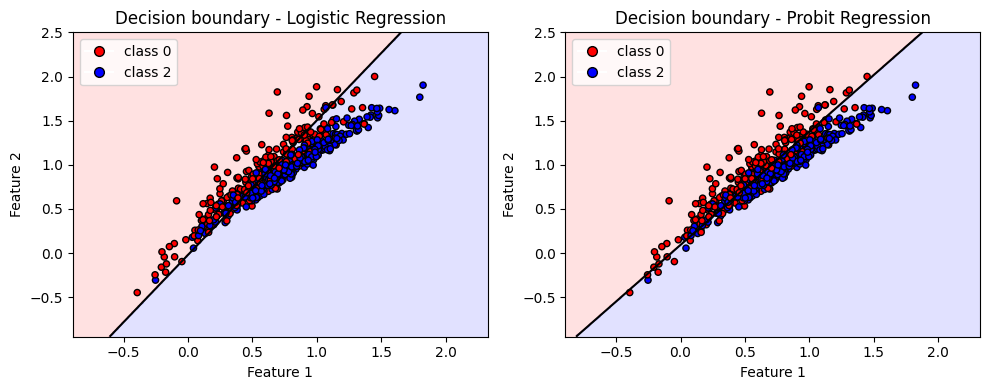

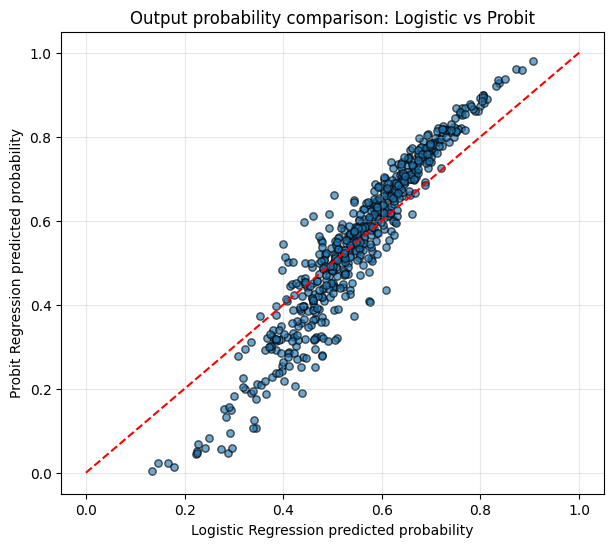

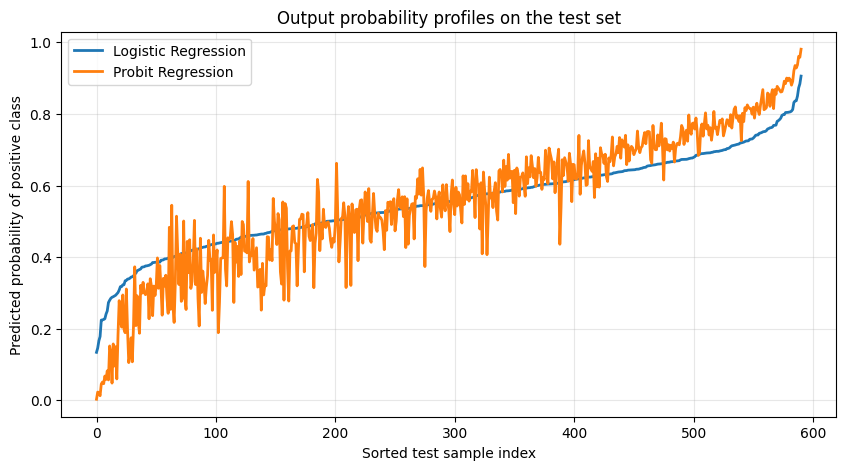

Iteration 0: Loss 0.6931
Iteration 1000: Loss 0.6727
Iteration 2000: Loss 0.6638
Iteration 3000: Loss 0.6563
Iteration 4000: Loss 0.6496
Iteration 5000: Loss 0.6436
Iteration 6000: Loss 0.6380
Iteration 7000: Loss 0.6327
Iteration 8000: Loss 0.6278
Iteration 9000: Loss 0.6231
Iteration 10000: Loss 0.6186
Iteration 11000: Loss 0.6144
Iteration 12000: Loss 0.6103
Iteration 13000: Loss 0.6063
Iteration 14000: Loss 0.6026
Iteration 15000: Loss 0.5990
Iteration 16000: Loss 0.5955
Iteration 17000: Loss 0.5921
Iteration 18000: Loss 0.5889
Iteration 19000: Loss 0.5858
Iteration 0: Loss 0.6931
Iteration 1000: Loss 0.6594
Iteration 2000: Loss 0.6427
Iteration 3000: Loss 0.6291
Iteration 4000: Loss 0.6172
Iteration 5000: Loss 0.6065
Iteration 6000: Loss 0.5970
Iteration 7000: Loss 0.5883
Iteration 8000: Loss 0.5804
Iteration 9000: Loss 0.5732
Iteration 10000: Loss 0.5666
Iteration 11000: Loss 0.5606
Iteration 12000: Loss 0.5551
Iteration 13000: Loss 0.5500
Iteration 14000: Loss 0.5454
Iteration 1

,noise_rate,logistic_accuracy,probit_accuracy,logistic_f1,probit_f1
0,0.0,0.746193,0.759729,0.738863,0.755038
1,0.1,0.746193,0.764805,0.737502,0.758746
2,0.2,0.741117,0.763113,0.740258,0.762263
3,0.3,0.580372,0.670051,0.469919,0.652762


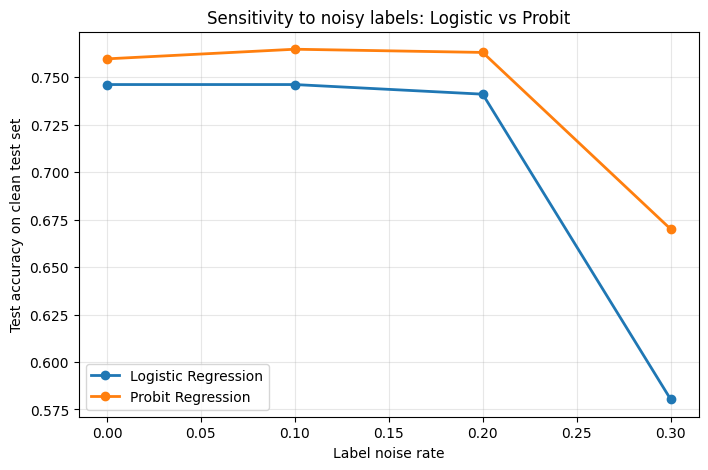

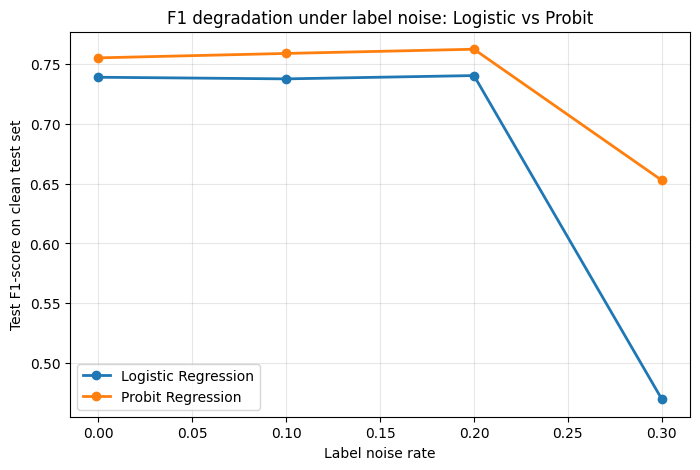

In [42]:
logreg_probit_cmp = build_from_config(LogisticRegression, logreg_cfg)
logreg_probit_cmp.fit(X=X_train_bin, y=y_train_bin)
models['Logistic Regression (Probit comparison)'] = logreg_probit_cmp

probit_cmp = build_from_config(ProbitRegression, probit_cfg)
probit_cmp.fit(X_train_bin, y_train_bin)
models['Probit Regression'] = probit_cmp

logreg_cmp_preds = logreg_probit_cmp.predict(X=X_test_bin)
logreg_cmp_eval = logreg_probit_cmp.evaluate(y_pred=logreg_cmp_preds, y_true=y_test_bin)
logreg_cmp_acc = logreg_cmp_eval['accuracy']

probit_cmp_preds = probit_cmp.predict(X_test_bin)
probit_cmp_eval = probit_cmp.evaluate(y_pred=probit_cmp_preds, y_true=y_test_bin)
probit_cmp_acc = probit_cmp_eval['accuracy']

print(f'Logistic Regression accuracy: {logreg_cmp_acc:.4f}')
print(f'Probit Regression accuracy: {probit_cmp_acc:.4f}')

boundary_models = {
  'Logistic Regression': logreg_probit_cmp,
  'Probit Regression': probit_cmp,
}
utils_module.plot_2d_decision_boundary(
  boundary_models,
  X_test_bin,
  y_test_bin,
  title_prefix='Decision boundary -',
)

logreg_cmp_proba = logreg_probit_cmp.predict_proba(X_test_bin)[:, 1]
probit_cmp_proba = probit_cmp.predict_proba(X_test_bin)[:, 1]

plt.figure(figsize=(7, 6))
plt.scatter(logreg_cmp_proba, probit_cmp_proba, alpha=0.65, edgecolor='k', s=28)
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5)
plt.xlabel('Logistic Regression predicted probability')
plt.ylabel('Probit Regression predicted probability')
plt.title('Output probability comparison: Logistic vs Probit')
plt.grid(alpha=0.3)
plt.show()

sample_order = np.argsort(logreg_cmp_proba)
plt.figure(figsize=(10, 5))
plt.plot(logreg_cmp_proba[sample_order], label='Logistic Regression', linewidth=2)
plt.plot(probit_cmp_proba[sample_order], label='Probit Regression', linewidth=2)
plt.xlabel('Sorted test sample index')
plt.ylabel('Predicted probability of positive class')
plt.title('Output probability profiles on the test set')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

noise_rates = [0.0, 0.1, 0.2, 0.3]
noise_rows = []
rng = np.random.default_rng(SEED)
negative_class, positive_class = np.unique(y_train_bin)

for noise_rate in noise_rates:
  y_train_noisy = y_train_bin.copy()
  if noise_rate > 0:
    flip_mask = rng.random(y_train_noisy.shape[0]) < noise_rate
    y_train_noisy[flip_mask] = np.where(
      y_train_noisy[flip_mask] == negative_class,
      positive_class,
      negative_class,
    )

  noisy_logreg = build_from_config(LogisticRegression, logreg_cfg)
  noisy_logreg.fit(X=X_train_bin, y=y_train_noisy)
  noisy_logreg_preds = noisy_logreg.predict(X=X_test_bin)
  noisy_logreg_eval = noisy_logreg.evaluate(y_pred=noisy_logreg_preds, y_true=y_test_bin)

  noisy_probit = build_from_config(ProbitRegression, probit_cfg)
  noisy_probit.fit(X_train_bin, y_train_noisy)
  noisy_probit_preds = noisy_probit.predict(X_test_bin)
  noisy_probit_eval = noisy_probit.evaluate(y_pred=noisy_probit_preds, y_true=y_test_bin)

  noise_rows.append({
    'noise_rate': noise_rate,
    'logistic_accuracy': noisy_logreg_eval['accuracy'],
    'probit_accuracy': noisy_probit_eval['accuracy'],
    'logistic_f1': noisy_logreg_eval['f1-score'],
    'probit_f1': noisy_probit_eval['f1-score'],
  })

noise_df = pd.DataFrame(noise_rows)
display(noise_df)

plt.figure(figsize=(8, 5))
plt.plot(noise_df['noise_rate'], noise_df['logistic_accuracy'], marker='o', linewidth=2, label='Logistic Regression')
plt.plot(noise_df['noise_rate'], noise_df['probit_accuracy'], marker='o', linewidth=2, label='Probit Regression')
plt.xlabel('Label noise rate')
plt.ylabel('Test accuracy on clean test set')
plt.title('Sensitivity to noisy labels: Logistic vs Probit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(noise_df['noise_rate'], noise_df['logistic_f1'], marker='o', linewidth=2, label='Logistic Regression')
plt.plot(noise_df['noise_rate'], noise_df['probit_f1'], marker='o', linewidth=2, label='Probit Regression')
plt.xlabel('Label noise rate')
plt.ylabel('Test F1-score on clean test set')
plt.title('F1 degradation under label noise: Logistic vs Probit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Bảng so sánh Probit và Logistic Regression


In [43]:
probit_logistic_summary = pd.DataFrame([
  {
    'model': 'Logistic Regression',
    'accuracy_clean': logreg_cmp_eval['accuracy'],
    'precision_clean': logreg_cmp_eval['precision'],
    'recall_clean': logreg_cmp_eval['recall'],
    'f1_clean': logreg_cmp_eval['f1-score'],
    'mean_predicted_prob': float(np.mean(logreg_cmp_proba)),
    'std_predicted_prob': float(np.std(logreg_cmp_proba)),
    'accuracy_at_30pct_noise': float(noise_df.loc[noise_df['noise_rate'] == 0.3, 'logistic_accuracy'].iloc[0]),
    'f1_at_30pct_noise': float(noise_df.loc[noise_df['noise_rate'] == 0.3, 'logistic_f1'].iloc[0]),
  },
  {
    'model': 'Probit Regression',
    'accuracy_clean': probit_cmp_eval['accuracy'],
    'precision_clean': probit_cmp_eval['precision'],
    'recall_clean': probit_cmp_eval['recall'],
    'f1_clean': probit_cmp_eval['f1-score'],
    'mean_predicted_prob': float(np.mean(probit_cmp_proba)),
    'std_predicted_prob': float(np.std(probit_cmp_proba)),
    'accuracy_at_30pct_noise': float(noise_df.loc[noise_df['noise_rate'] == 0.3, 'probit_accuracy'].iloc[0]),
    'f1_at_30pct_noise': float(noise_df.loc[noise_df['noise_rate'] == 0.3, 'probit_f1'].iloc[0]),
  },
])

display(probit_logistic_summary)


,model,accuracy_clean,precision_clean,recall_clean,f1_clean,mean_predicted_prob,std_predicted_prob,accuracy_at_30pct_noise,f1_at_30pct_noise
0,Logistic Regression,0.746193,0.755552,0.746193,0.738863,0.553419,0.125931,0.580372,0.469919
1,Probit Regression,0.759729,0.764791,0.759729,0.755038,0.553170,0.192470,0.670051,0.652762


## 3.5 Kernel Logistic Regression

`Kernel Logistic Regression`: cài đặt dual formulation với `RBF kernel`, sau đó so sánh với mô hình tuyến tính trên dữ liệu không phân chia tuyến tính (`XOR-like patterns`).

Ý tưởng chính:
- Mô hình tuyến tính thông thường không thể biểu diễn tốt biên quyết định kiểu XOR.
- `Kernel Logistic Regression` dùng kernel trick để làm việc trong không gian đặc trưng ẩn, từ đó học được biên quyết định phi tuyến trong không gian gốc.
- Phần dưới đây dùng `Perceptron` như một baseline tuyến tính để đối chiếu với `Kernel Logistic Regression` trên cùng bối cảnh dữ liệu.


In [44]:
klr = build_from_config(KernelLogisticRegression, kernel_log_cfg)
klr.fit(X_train_bin, y_train_bin)
models['KLR'] = klr

klr_preds = klr.predict(X=X_test_bin)
klr_eval = klr.evaluate(y_pred=klr_preds, y_true=y_test_bin)
print('Kernel Logistic Regression Binary Evaluation:', logreg_eval)

Iteration 0: Loss 0.6932
Iteration 1000: Loss 1.0618
Iteration 2000: Loss 1.0005
Iteration 3000: Loss 0.9550
Iteration 4000: Loss 0.9137
Iteration 5000: Loss 0.8736
Iteration 6000: Loss 0.8352
Iteration 7000: Loss 0.7992
Iteration 8000: Loss 0.7666
Iteration 9000: Loss 0.7377
Iteration 10000: Loss 0.7127
Iteration 11000: Loss 0.6910
Iteration 12000: Loss 0.6726
Iteration 13000: Loss 0.6568
Iteration 14000: Loss 0.6435
Iteration 15000: Loss 0.6323
Iteration 16000: Loss 0.6228
Iteration 17000: Loss 0.6148
Iteration 18000: Loss 0.6082
Iteration 19000: Loss 0.6026
Kernel Logistic Regression Binary Evaluation: {'accuracy': 0.7461928934010152, 'precision': 0.7555519106804107, 'recall': 0.7461928934010152, 'f1-score': 0.7388632326951119, 'macro_avg': {'precision': 0.7595164943890436, 'recall': 0.7307500868156036, 'f1-score': 0.7326533812637217}, 'weighted_avg': {'precision': 0.7555519106804107, 'recall': 0.7461928934010152, 'f1-score': 0.7388632326951119}, 'classification_report': {'selected_

### Tạo dữ liệu XOR-like và huấn luyện baseline tuyến tính

Cell bên dưới tạo một tập dữ liệu `XOR-like` 2 chiều, sau đó huấn luyện `Perceptron` như một mô hình tuyến tính baseline. Đây là bối cảnh phù hợp để kiểm tra xem mô hình tuyến tính thất bại ra sao khi dữ liệu không phân chia tuyến tính.


In [45]:
rng = np.random.default_rng(SEED)
n_xor = 600
X_xor = rng.normal(0.0, 1.0, size=(n_xor, 2))
y_xor = ((X_xor[:, 0] * X_xor[:, 1]) > 0).astype(int)

xor_perm = rng.permutation(n_xor)
split_idx = int(0.8 * n_xor)
train_idx, test_idx = xor_perm[:split_idx], xor_perm[split_idx:]

X_train_xor, y_train_xor = X_xor[train_idx], y_xor[train_idx]
X_test_xor, y_test_xor = X_xor[test_idx], y_xor[test_idx]

perceptron_xor = build_from_config(Perceptron, perceptron_cfg)
perceptron_xor.fit(X_train_xor, y_train_xor)

perceptron_xor_preds = perceptron_xor.predict(X_test_xor)
perceptron_xor_eval = perceptron_xor.evaluate(y_pred=perceptron_xor_preds, y_true=y_test_xor)
print(f"Perceptron accuracy on XOR-like test set: {perceptron_xor_eval['accuracy']:.4f}")

Perceptron accuracy on XOR-like test set: 0.3083


### Huấn luyện Kernel Logistic Regression với RBF kernel trên dữ liệu XOR-like

Cell bên dưới huấn luyện `Kernel Logistic Regression` theo `dual formulation` với `RBF kernel` trên cùng dữ liệu `XOR-like`, sau đó so sánh trực tiếp với baseline tuyến tính bằng cả biểu đồ biên quyết định và bảng kết quả.


Iteration 0: Loss 0.6931
Iteration 1000: Loss 0.2625
Iteration 2000: Loss 0.2112
Iteration 3000: Loss 0.1893
Iteration 4000: Loss 0.1771
Iteration 5000: Loss 0.1693
Iteration 6000: Loss 0.1639
Iteration 7000: Loss 0.1600
Iteration 8000: Loss 0.1570
Iteration 9000: Loss 0.1548
Iteration 10000: Loss 0.1530
Iteration 11000: Loss 0.1515
Iteration 12000: Loss 0.1504
Kernel Logistic Regression accuracy on XOR-like test set: 0.9917


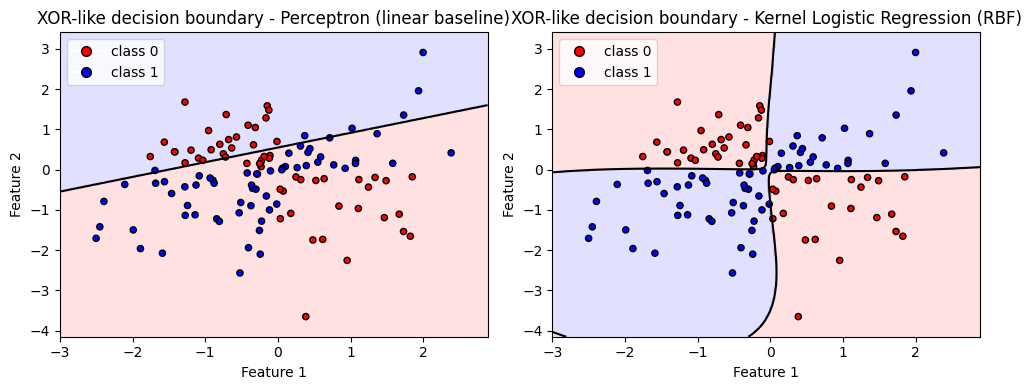

,model,accuracy,precision,recall,f1
0,Perceptron (linear baseline),0.308333,0.265773,0.308333,0.266909
1,Kernel Logistic Regression (RBF),0.991667,0.991795,0.991667,0.991661


In [46]:
kernel_xor_cfg = KernelLogisticRegressionConfig(
  kernel='rbf',
  gamma=kernel_log_cfg.gamma,
  lam=kernel_log_cfg.lam,
  learning_rate=kernel_log_cfg.learning_rate,
  eps=kernel_log_cfg.eps,
  max_iter=kernel_log_cfg.max_iter,
  min_iter=kernel_log_cfg.min_iter,
)

kernel_model = build_from_config(KernelLogisticRegression, kernel_xor_cfg)
kernel_model.fit(X_train_xor, y_train_xor)

kernel_xor_preds = kernel_model.predict(X_test_xor)
kernel_xor_eval = kernel_model.evaluate(y_pred=kernel_xor_preds, y_true=y_test_xor)
print(f"Kernel Logistic Regression accuracy on XOR-like test set: {kernel_xor_eval['accuracy']:.4f}")

xor_boundary_models = {
  'Perceptron (linear baseline)': perceptron_xor,
  'Kernel Logistic Regression (RBF)': kernel_model,
}
utils_module.plot_2d_decision_boundary(
  xor_boundary_models,
  X_test_xor,
  y_test_xor,
  title_prefix='XOR-like decision boundary -',
)

kernel_vs_linear_summary = pd.DataFrame([
  {
    'model': 'Perceptron (linear baseline)',
    'accuracy': perceptron_xor_eval['accuracy'],
    'precision': perceptron_xor_eval['precision'],
    'recall': perceptron_xor_eval['recall'],
    'f1': perceptron_xor_eval['f1-score'],
  },
  {
    'model': 'Kernel Logistic Regression (RBF)',
    'accuracy': kernel_xor_eval['accuracy'],
    'precision': kernel_xor_eval['precision'],
    'recall': kernel_xor_eval['recall'],
    'f1': kernel_xor_eval['f1-score'],
  },
])

display(kernel_vs_linear_summary)

## 3.6 VC dimension

Phân tích `VC dimension`: tính VC dimension của lớp phân lớp tuyến tính trong $\mathbb{R}^D$ và liên hệ với tổng quát hóa thông qua `structural risk minimization`.

Với lớp bộ phân lớp tuyến tính trong $\mathbb{R}^D$ (siêu phẳng có bias), VC dimension bằng $D+1$. Điều này cho biết năng lực biểu diễn của mô hình tăng tuyến tính theo số chiều đặc trưng.

Liên hệ với `structural risk minimization (SRM)`:
- Khi tăng số đặc trưng hoặc dùng ánh xạ đặc trưng làm $D$ lớn hơn, biên quyết định linh hoạt hơn nhưng độ phức tạp giả thuyết tăng (VC dim tăng), dễ overfitting nếu dữ liệu hữu hạn.
- Regularization (L1/L2) đóng vai trò kiểm soát độ phức tạp hiệu dụng, giúp cân bằng giữa empirical risk và capacity.
- Trong các kết quả thực nghiệm ở notebook này, các mô hình tuyến tính có regularization thường ổn định hơn trên CV so với cấu hình không regularization mạnh, phù hợp với trực giác từ SRM.


# 4. Đánh giá mô hình <a id='4'></a>

Nguyên tắc đánh giá xuyên suốt:

- Không dựa vào một metric duy nhất; cần kết hợp Accuracy, Precision/Recall/F1, PR/AP, ROC/AUC và calibration.
- Đánh giá trên cùng một tập test để so sánh công bằng giữa các mô hình.
- Dùng k-fold CV để kiểm tra tính ổn định theo phép chia dữ liệu.
- Dùng kiểm định thống kê (McNemar) để tránh kết luận dựa trên chênh lệch ngẫu nhiên nhỏ.


## 4.1 Đồ thị hàm mất mát theo số vòng lặp

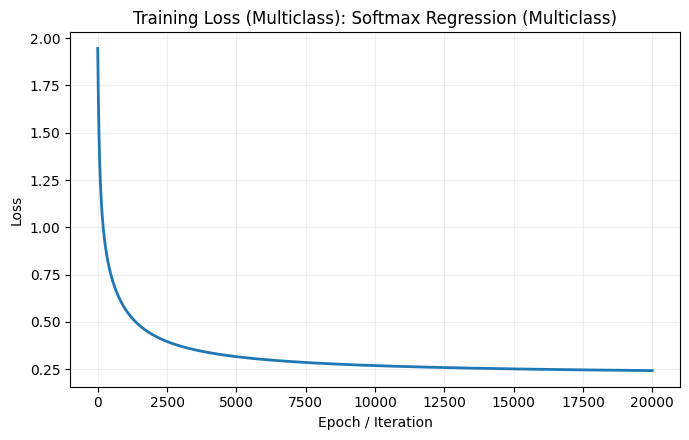

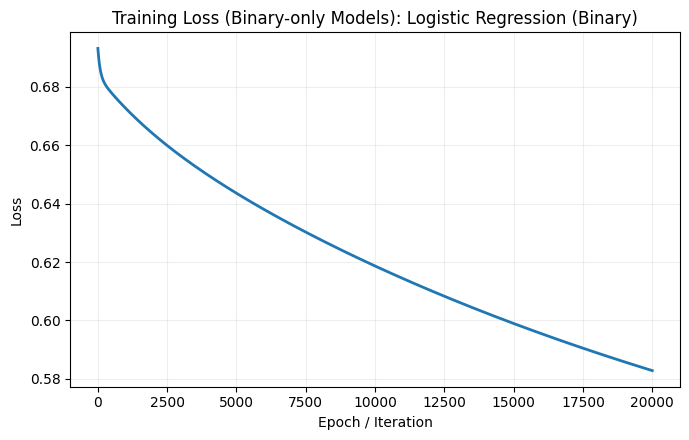

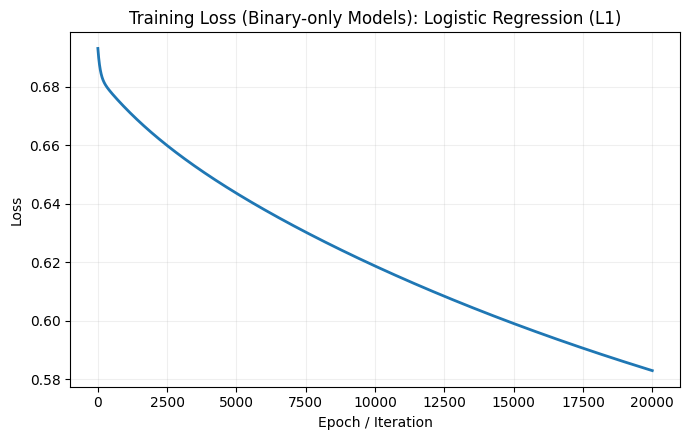

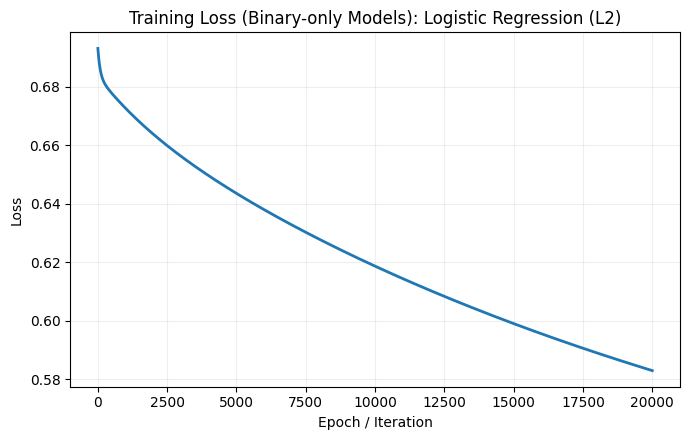

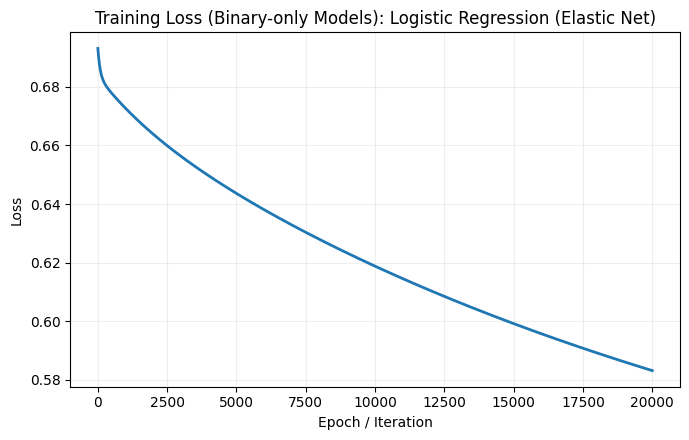

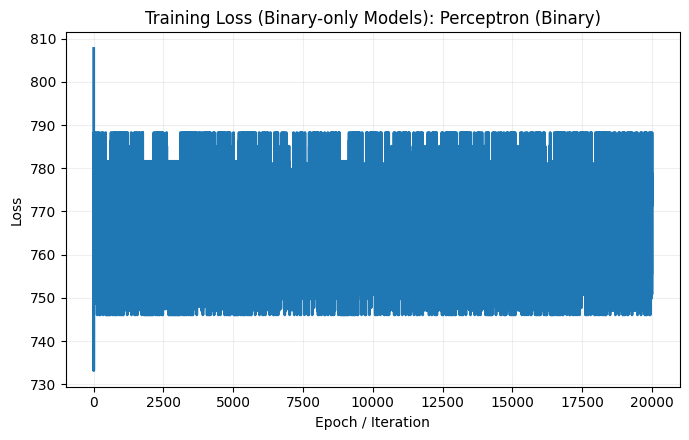

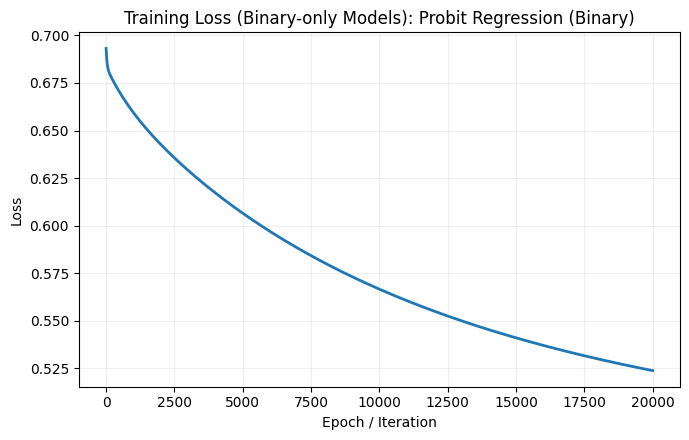

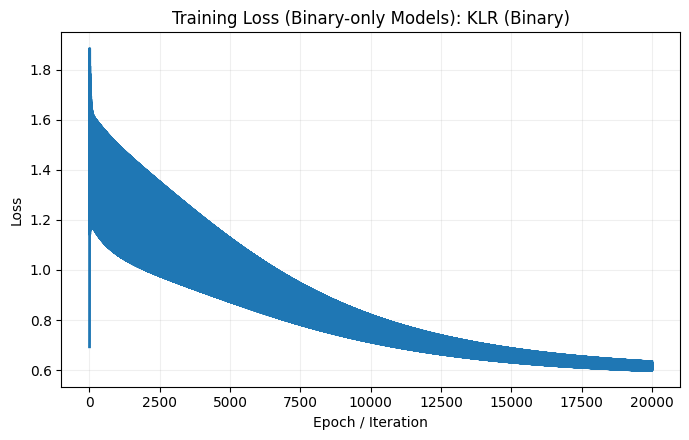

In [47]:
multiclass_loss_candidates = {
  'Softmax Regression (Multiclass)': softmax_model,
}
multiclass_models_to_plot = collect_models_with_attr(multiclass_loss_candidates, 'loss_history_')

if multiclass_models_to_plot:
  plot_loss_curves_separately(multiclass_models_to_plot, title_prefix='Training Loss (Multiclass)')
else:
  print('No multiclass model with loss history was found.')

binary_loss_candidates = {
  'Logistic Regression (Binary)': logreg,
  'Logistic Regression (L1)': logreg_l1,
  'Logistic Regression (L2)': logreg_l2,
  'Logistic Regression (Elastic Net)': logreg_elastic,
  'Perceptron (Binary)': perceptron_clf,
  'Probit Regression (Binary)': probit_model,
  'KLR (Binary)': klr,
}
binary_models_to_plot = collect_models_with_attr(binary_loss_candidates, 'loss_history_')

if binary_models_to_plot:
  plot_loss_curves_separately(binary_models_to_plot, title_prefix='Training Loss (Binary-only Models)')

## 4.2 Vẽ đường ranh giới quyết định trong không gian 2D

Vẽ đường ranh giới quyết định cho tập nhị phân 2D:


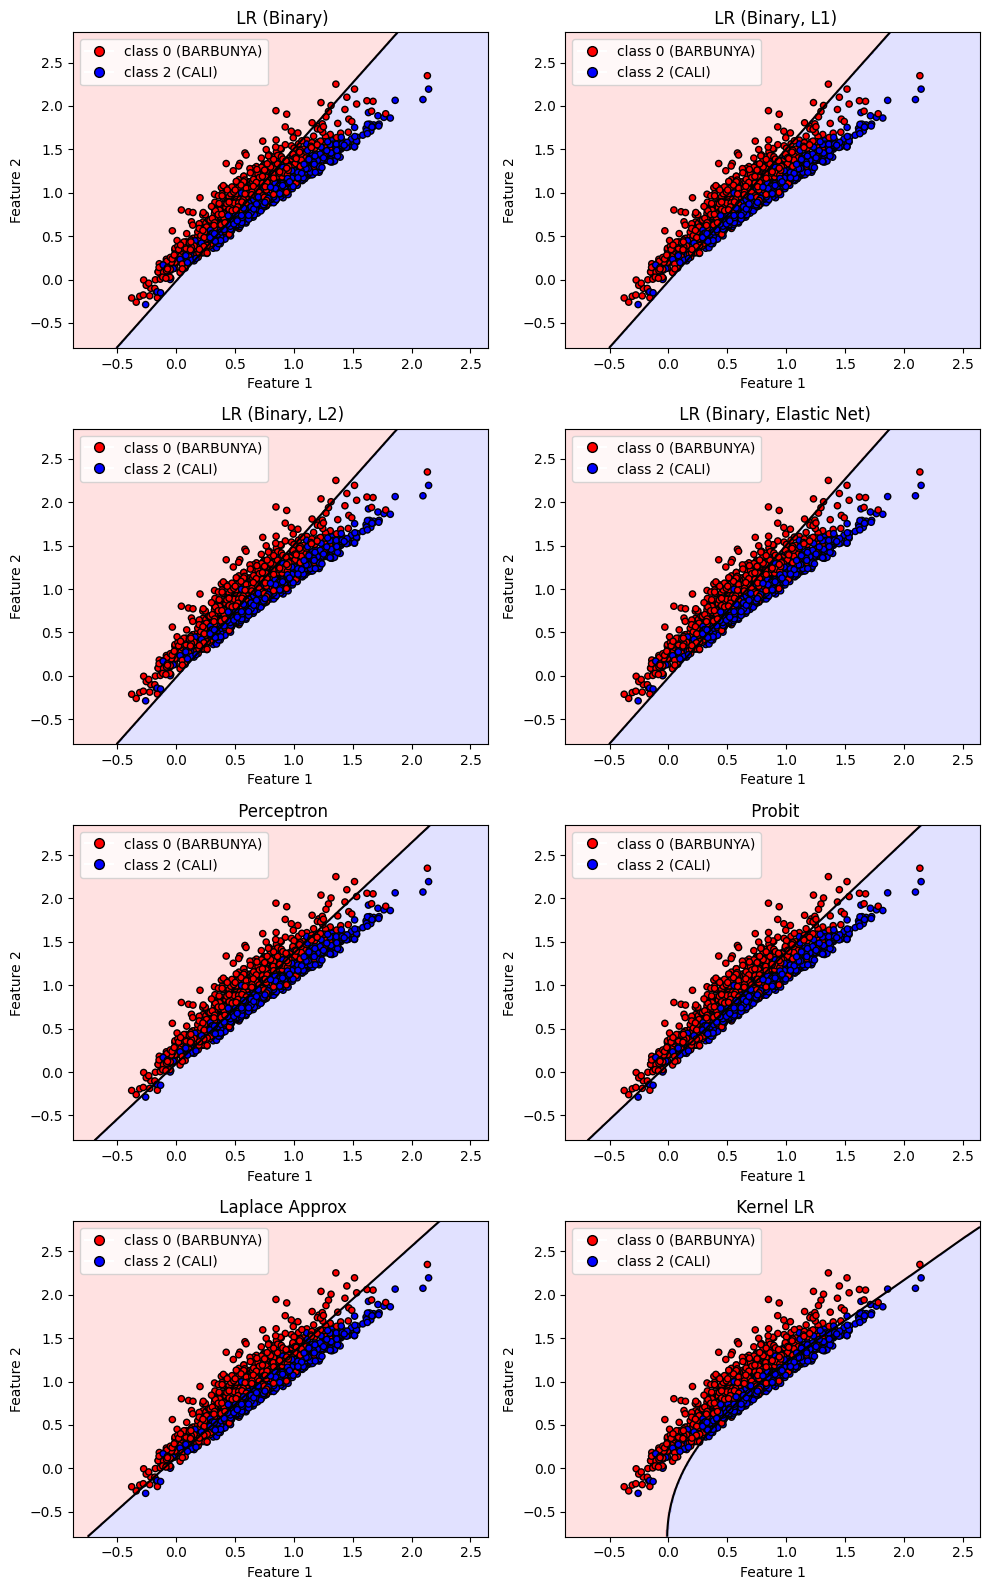

In [48]:
# Collect binary models trained on 2D space (X_train_bin) earlier.
binary_2d_candidates = {
  'LR (Binary)': logreg,
  'LR (Binary, L1)': logreg_l1,
  'LR (Binary, L2)': logreg_l2,
  'LR (Binary, Elastic Net)': logreg_elastic,
  'Perceptron': perceptron_clf,
  'Probit': probit_model,
  'Laplace Approx': blr,
  'Kernel LR': klr,
}
binary_2d_models = collect_models_with_attr(binary_2d_candidates, 'predict')

if binary_2d_models:
  print('Vẽ đường ranh giới quyết định cho tập nhị phân 2D:')
  binary_class_name_map = {
    int(BINARY_CLASSES[0]): str(target_le.classes_[BINARY_CLASSES[0]]),
    int(BINARY_CLASSES[1]): str(target_le.classes_[BINARY_CLASSES[1]]),
  }

  utils_module.plot_2d_decision_boundary(
    binary_2d_models,
    X_train_bin,
    y_train_bin,
    class_name_map=binary_class_name_map,
  )
else:
  print('Không tìm thấy mô hình nhị phân 2D nào được huấn luyện trước đó.')

## 4.3 So sánh tất cả các mô hình trong một bảng kết quả thống nhất

Bảng so sánh chính (multiclass):


,model,task_type,n_classes,accuracy,precision,recall,f1-score
1,Softmax Regression,multiclass,7,0.917738,0.918833,0.917738,0.917966
4,QDA,multiclass,7,0.907088,0.911746,0.907088,0.907648
3,LDA,multiclass,7,0.900477,0.912638,0.900477,0.902211
5,Gaussian Naive Bayes,multiclass,7,0.899008,0.901879,0.899008,0.899110


Bảng tham chiếu (binary-only models, không dùng để kết luận chính cho multiclass):


,model,task_type,n_classes,accuracy,precision,recall,f1-score
2,Bayesian Logistic Regression (Laplace),binary_only,2,0.759729,0.761935,0.759729,0.756448
6,Perceptron (Binary),binary_only,2,0.759729,0.763229,0.759729,0.755772
11,Probit Regression,binary_only,2,0.759729,0.764791,0.759729,0.755038
0,Logistic Regression (Binary),binary_only,2,0.746193,0.755552,0.746193,0.738863
8,"Logistic Regression (Binary, L2)",binary_only,2,0.746193,0.755552,0.746193,0.738863
7,"Logistic Regression (Binary, L1)",binary_only,2,0.746193,0.755552,0.746193,0.738863
9,"Logistic Regression (Binary, Elastic Net)",binary_only,2,0.746193,0.755552,0.746193,0.738863
12,Logistic Regression (Probit comparison),binary_only,2,0.746193,0.755552,0.746193,0.738863
10,"Logistic Regression (Binary, L2, class-weighted)",binary_only,2,0.719120,0.721704,0.719120,0.719746
13,KLR,binary_only,2,0.686971,0.731504,0.686971,0.681359


<Figure size 800x600 with 0 Axes>

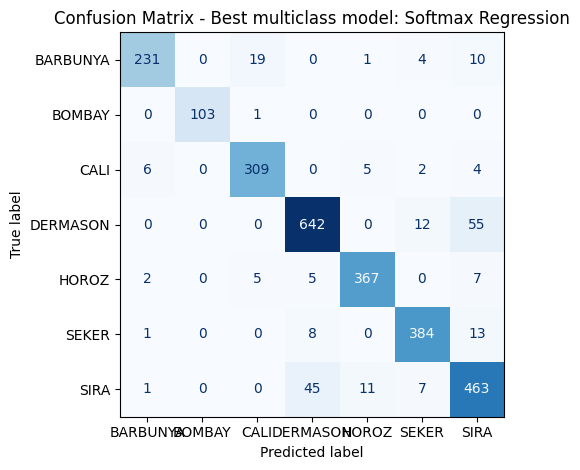

Misclassified samples for Softmax Regression: 224/2723
Top confusion pairs (true -> predicted):


,true_label,pred_label,count
0,DERMASON,SIRA,55
1,SIRA,DERMASON,45
2,BARBUNYA,CALI,19
3,SEKER,SIRA,13
4,DERMASON,SEKER,12
5,SIRA,HOROZ,11
6,BARBUNYA,SIRA,10
7,SEKER,DERMASON,8
8,SIRA,SEKER,7
9,HOROZ,SIRA,7


Top features with largest absolute mean shift for the hardest confusion pair:


ConvexArea         9095.018663
Area               8994.906400
Perimeter            95.139991
MajorAxisLength      38.791262
EquivDiameter        27.244692
MinorAxisLength      18.860861
AspectRation          0.058194
ShapeFactor3          0.026906
dtype: float64

In [49]:
summary_rows = []
pred_cache = {}

for model_name, model in models.items():
  if not hasattr(model, 'predict'):
    continue

  classes = np.asarray(getattr(model, 'classes_', np.array([])))
  is_binary_model = classes.shape[0] == 2
  eval_X = X_test_bin if is_binary_model else X_test_scaled
  eval_y = y_test_bin if is_binary_model else y_test

  try:
    y_pred = model.predict(eval_X)
  except Exception as e:
    print(f'Skip {model_name}: {e}')
    continue

  metrics = classification_report(y_pred, eval_y, average='weighted')
  summary_rows.append({
    'model': model_name,
    'task_type': 'binary_only' if is_binary_model else 'multiclass',
    'n_classes': int(np.unique(eval_y).shape[0]),
    'accuracy': metrics['accuracy'],
    'precision': metrics['precision'],
    'recall': metrics['recall'],
    'f1-score': metrics['f1-score'],
  })
  pred_cache[model_name] = (eval_y, y_pred)

results_df = pd.DataFrame(summary_rows)

multiclass_df = results_df[results_df['task_type'] == 'multiclass'].sort_values('f1-score', ascending=False)
print('Bảng so sánh chính (multiclass):')
display(multiclass_df)

binary_df = results_df[results_df['task_type'] == 'binary_only'].sort_values('f1-score', ascending=False)
if binary_df.shape[0] > 0:
  print('Bảng tham chiếu (binary-only models, không dùng để kết luận chính cho multiclass):')
  display(binary_df)

# Confusion matrix cho mô hình multiclass tốt nhất.
if multiclass_df.shape[0] > 0:
  best_mc_name = multiclass_df.iloc[0]['model']
  y_true_mc, y_pred_mc = pred_cache[best_mc_name]
  labels_mc = np.unique(y_true_mc)

  cm = confusion_matrix(y_true_mc, y_pred_mc, labels=labels_mc)
  plt.figure(figsize=(8, 6))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_le.classes_)
  disp.plot(cmap='Blues', values_format='d', colorbar=False)
  plt.title(f'Confusion Matrix - Best multiclass model: {best_mc_name}')
  plt.tight_layout()
  plt.show()

  mis_idx = np.where(y_true_mc != y_pred_mc)[0]
  print(f'Misclassified samples for {best_mc_name}: {mis_idx.size}/{y_true_mc.shape[0]}')

  if mis_idx.size > 0:
    error_pairs = pd.DataFrame({
      'true': y_true_mc[mis_idx],
      'pred': y_pred_mc[mis_idx],
    })
    pair_counts = (
      error_pairs
      .value_counts()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
    )

    pair_counts['true_label'] = target_le.inverse_transform(pair_counts['true'].astype(int))
    pair_counts['pred_label'] = target_le.inverse_transform(pair_counts['pred'].astype(int))

    print('Top confusion pairs (true -> predicted):')
    display(pair_counts[['true_label', 'pred_label', 'count']].head(10))

    if isinstance(X_test, pd.DataFrame):
      X_test_df = X_test.reset_index(drop=True)
    else:
      X_test_df = pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(X_test.shape[1])])

    top_pair_true = int(pair_counts.iloc[0]['true'])
    top_pair_pred = int(pair_counts.iloc[0]['pred'])

    pair_mask = (y_true_mc == top_pair_true) & (y_pred_mc == top_pair_pred)
    correct_mask_same_true = (y_true_mc == top_pair_true) & (y_pred_mc == y_true_mc)

    if np.any(pair_mask) and np.any(correct_mask_same_true):
      mean_diff = (
        X_test_df.loc[np.where(pair_mask)[0]].mean()
        - X_test_df.loc[np.where(correct_mask_same_true)[0]].mean()
      )
      print('Top features with largest absolute mean shift for the hardest confusion pair:')
      display(mean_diff.abs().sort_values(ascending=False).head(8))
else:
  print('No multiclass model available for confusion matrix plotting.')

## 4.4 k-fold cross-validation (k=5) và báo cáo $\text{mean} \pm \text{std}$ cho mỗi chỉ số

In [50]:
retrained_models = {
  'Softmax Regression': lambda: build_from_config(SoftmaxRegression, softmax_cfg),
  'LDA': lambda: build_from_config(LDA, lda_cfg),
  'QDA': lambda: build_from_config(QDA, qda_cfg),
  'Gaussian Naive Bayes': lambda: build_from_config(GaussianNaiveBayes, gnb_cfg),
}

metric_order = ['accuracy', 'precision', 'recall', 'f1-score']
cv_rows = []

for model_name, builder in retrained_models.items():
  result = kfold_cross_val_score(
    model=builder(),
    X=X_train_scaled,
    y=y_train,
    k=KFOLD_SPLITS,
    average='weighted',
    random_state=SEED,
    shuffle=True,
    model_builder=builder,
  )

  row = {'Model': model_name}
  for metric in metric_order:
    row[metric] = result['summary'][metric]['mean_std']
  cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).set_index('Model')
print(f'{KFOLD_SPLITS}-fold cross-validation results (mean +- std):')
cv_df

Iteration 0: Loss 1.9459
Iteration 1000: Loss 0.5647
Iteration 2000: Loss 0.4286
Iteration 3000: Loss 0.3688
Iteration 4000: Loss 0.3350
Iteration 5000: Loss 0.3132
Iteration 6000: Loss 0.2980
Iteration 7000: Loss 0.2867
Iteration 8000: Loss 0.2780
Iteration 9000: Loss 0.2710
Iteration 10000: Loss 0.2654
Iteration 11000: Loss 0.2607
Iteration 12000: Loss 0.2567
Iteration 13000: Loss 0.2533
Iteration 14000: Loss 0.2503
Iteration 15000: Loss 0.2478
Iteration 16000: Loss 0.2455
Iteration 17000: Loss 0.2435
Iteration 18000: Loss 0.2417
Iteration 19000: Loss 0.2401
Iteration 0: Loss 1.9459
Iteration 1000: Loss 0.5666
Iteration 2000: Loss 0.4316
Iteration 3000: Loss 0.3723
Iteration 4000: Loss 0.3388
Iteration 5000: Loss 0.3172
Iteration 6000: Loss 0.3021
Iteration 7000: Loss 0.2909
Iteration 8000: Loss 0.2823
Iteration 9000: Loss 0.2755
Iteration 10000: Loss 0.2699
Iteration 11000: Loss 0.2652
Iteration 12000: Loss 0.2613
Iteration 13000: Loss 0.2579
Iteration 14000: Loss 0.2550
Iteration 1

,accuracy,precision,recall,f1-score
Model,,,,
Softmax Regression,0.9210 +- 0.0013,0.9216 +- 0.0014,0.9210 +- 0.0013,0.9210 +- 0.0014
LDA,0.9012 +- 0.0072,0.9126 +- 0.0070,0.9012 +- 0.0072,0.9030 +- 0.0072
QDA,0.9112 +- 0.0065,0.9148 +- 0.0061,0.9112 +- 0.0065,0.9116 +- 0.0065
Gaussian Naive Bayes,0.8959 +- 0.0037,0.8971 +- 0.0040,0.8959 +- 0.0037,0.8959 +- 0.0037


## 4.5 Vẽ **Precision-Recall curve** và so sánh Average Precision (AP) giữa các mô hình

**Cơ sở lý thuyết (ngắn gọn):**
- Precision-Recall phù hợp khi dữ liệu có thể mất cân bằng lớp.
- AP (Average Precision) tóm tắt toàn bộ đường PR thành một giá trị, giúp so sánh mô hình ổn định hơn chỉ nhìn một ngưỡng phân loại.
- Mô hình tốt hơn thường có đường PR nằm cao hơn và AP lớn hơn trên cùng tập đánh giá.

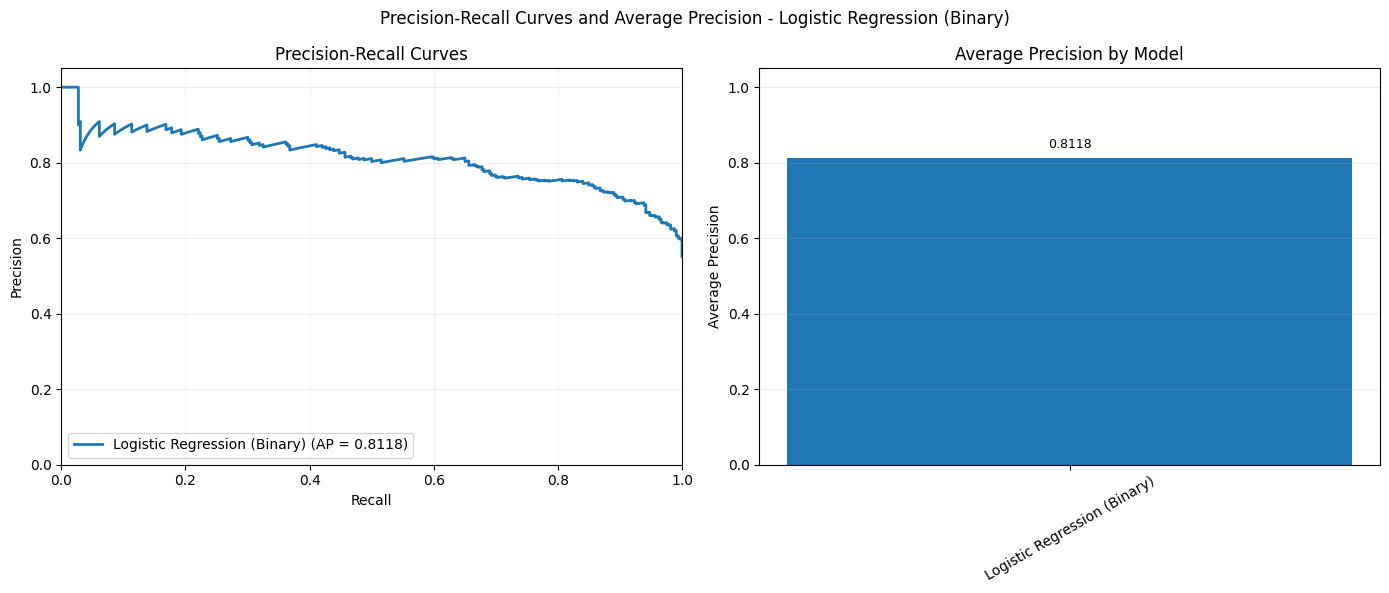

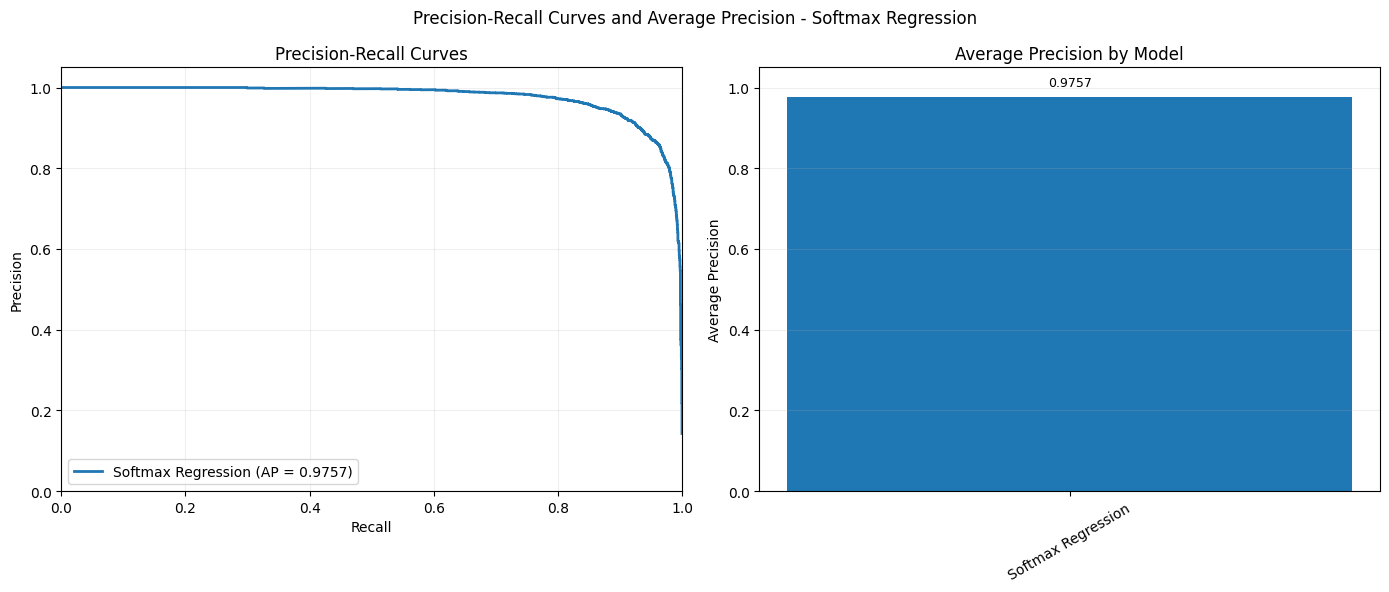

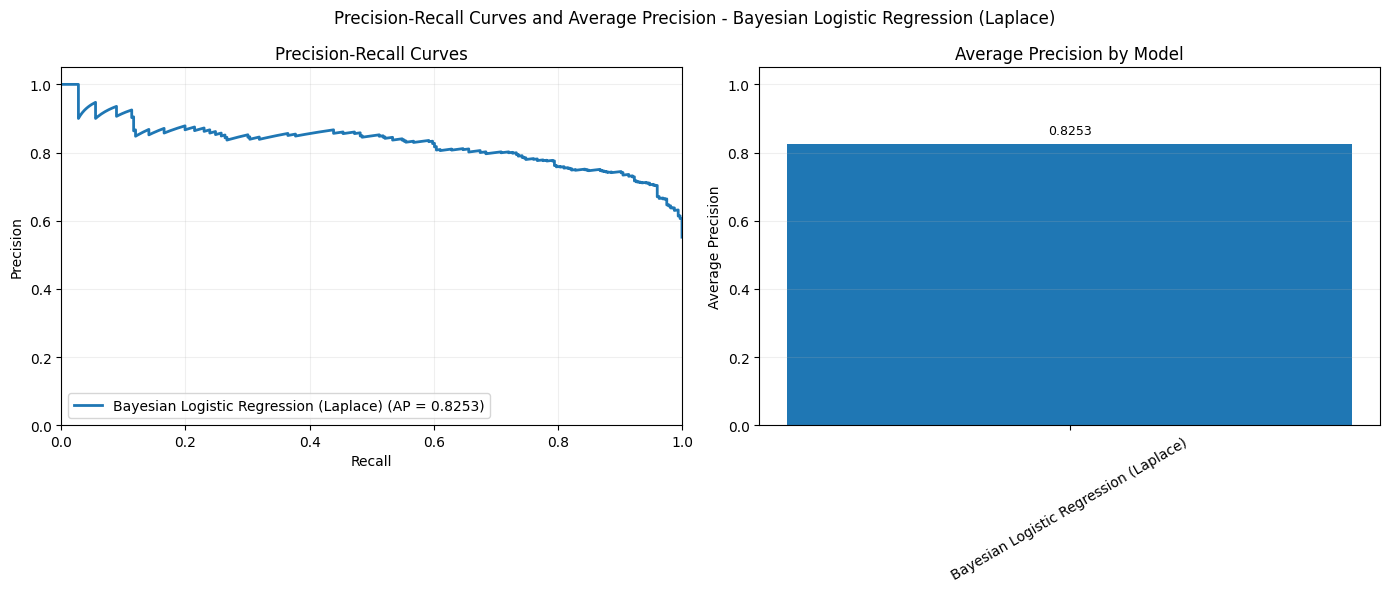

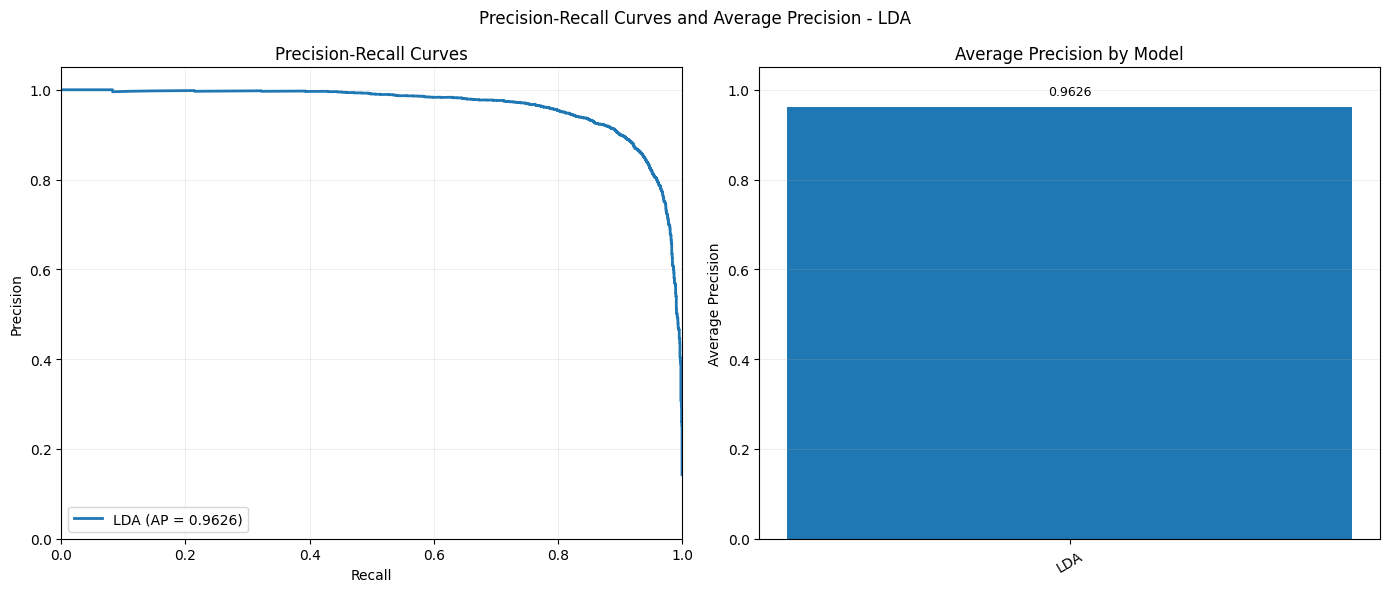

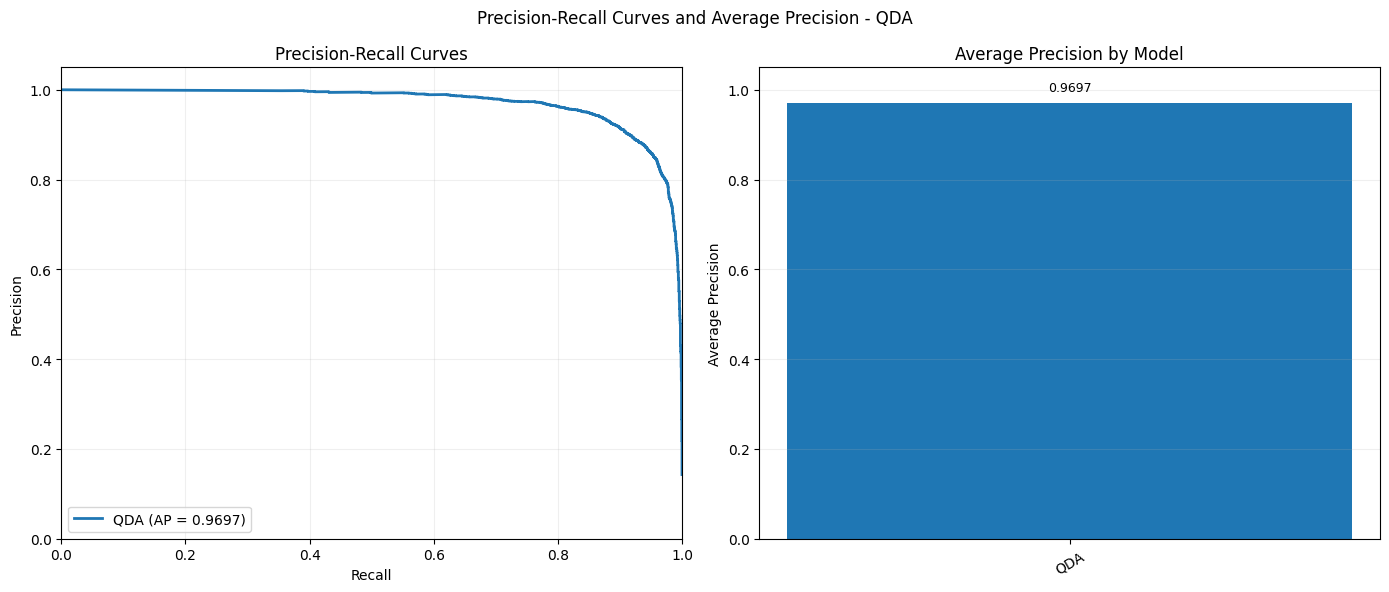

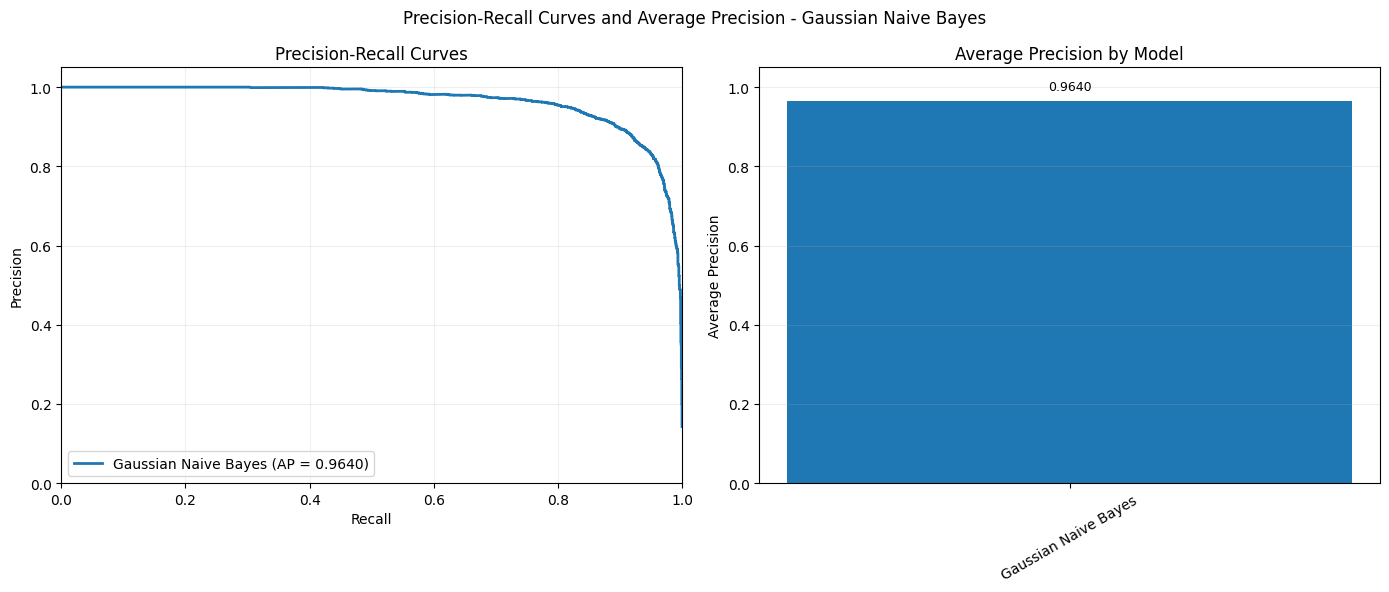

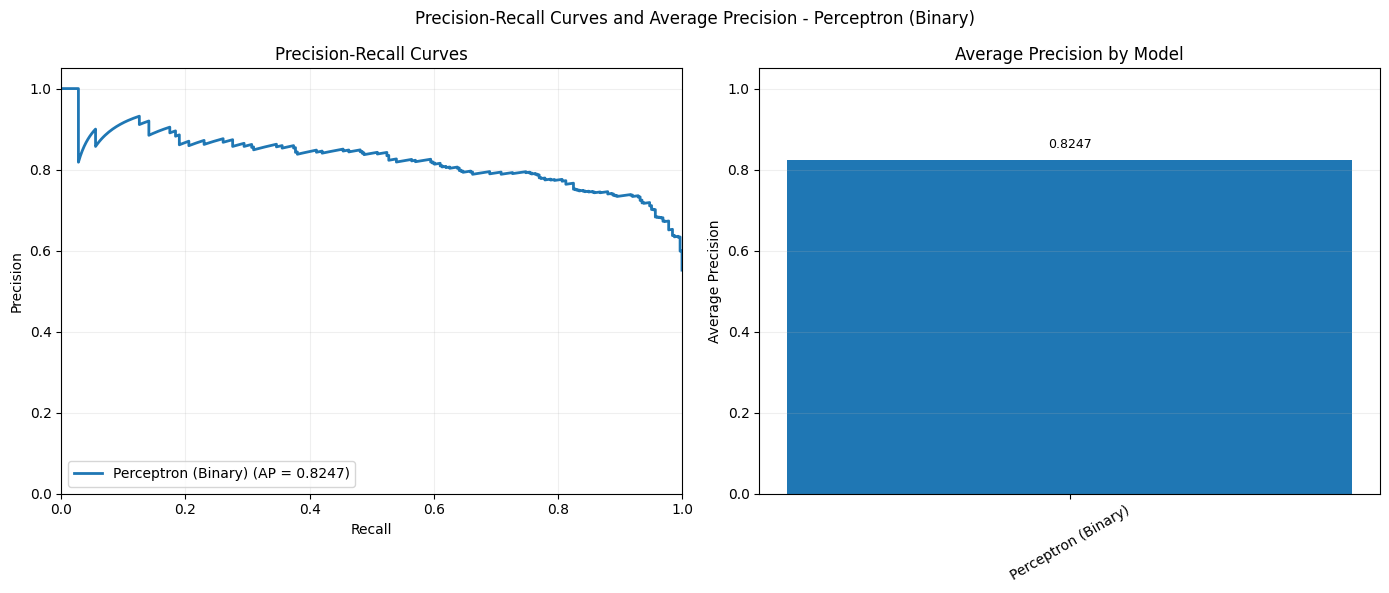

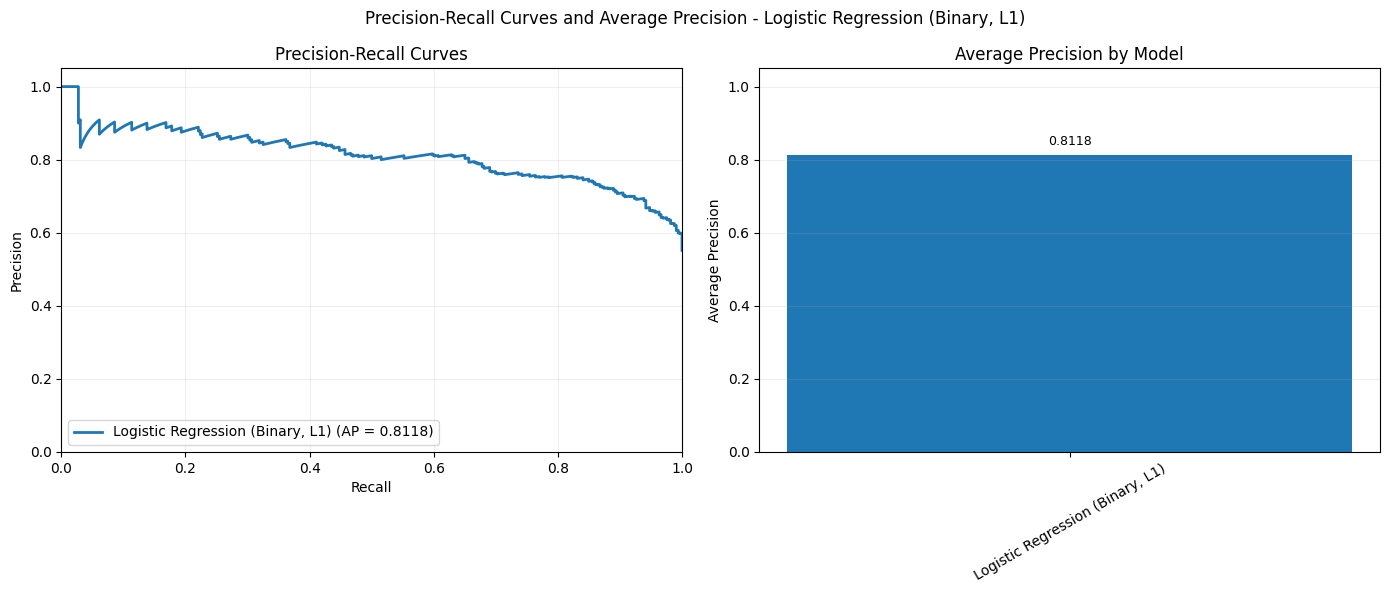

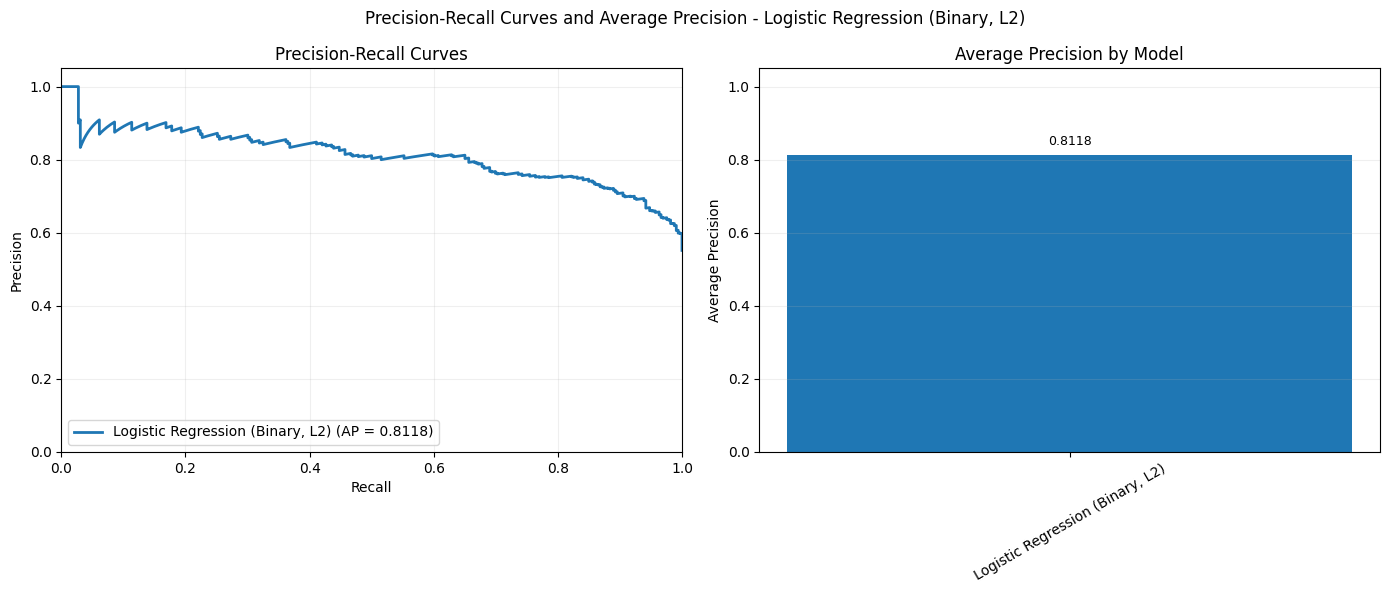

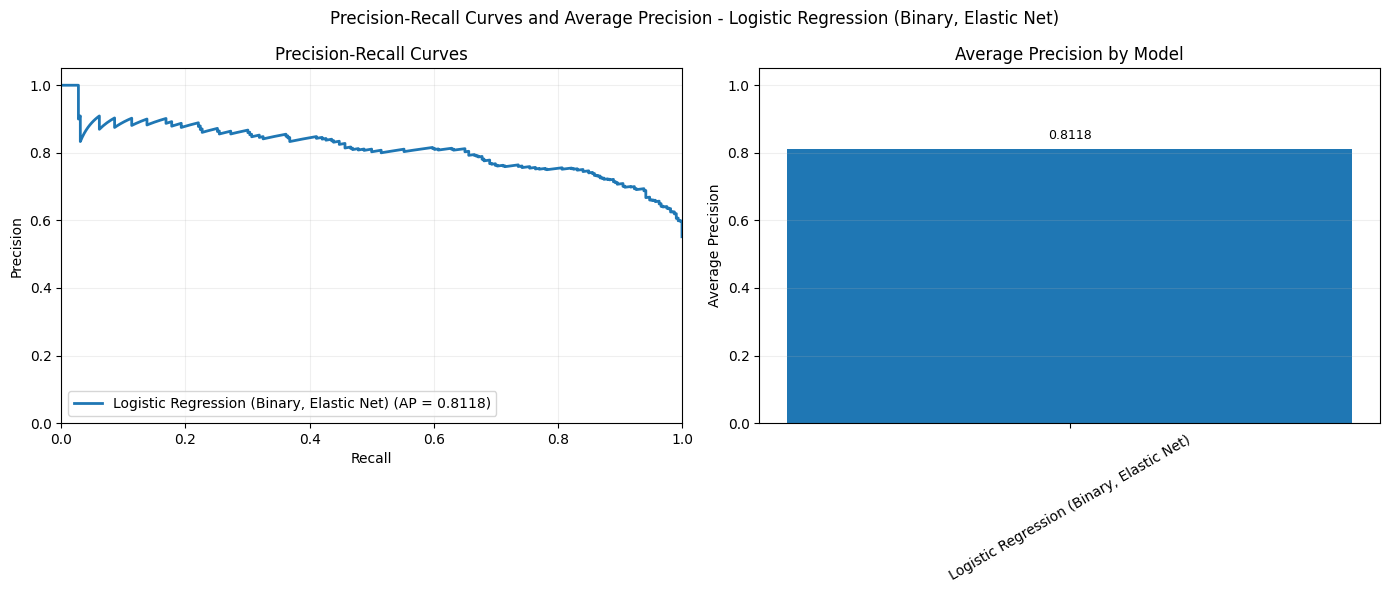

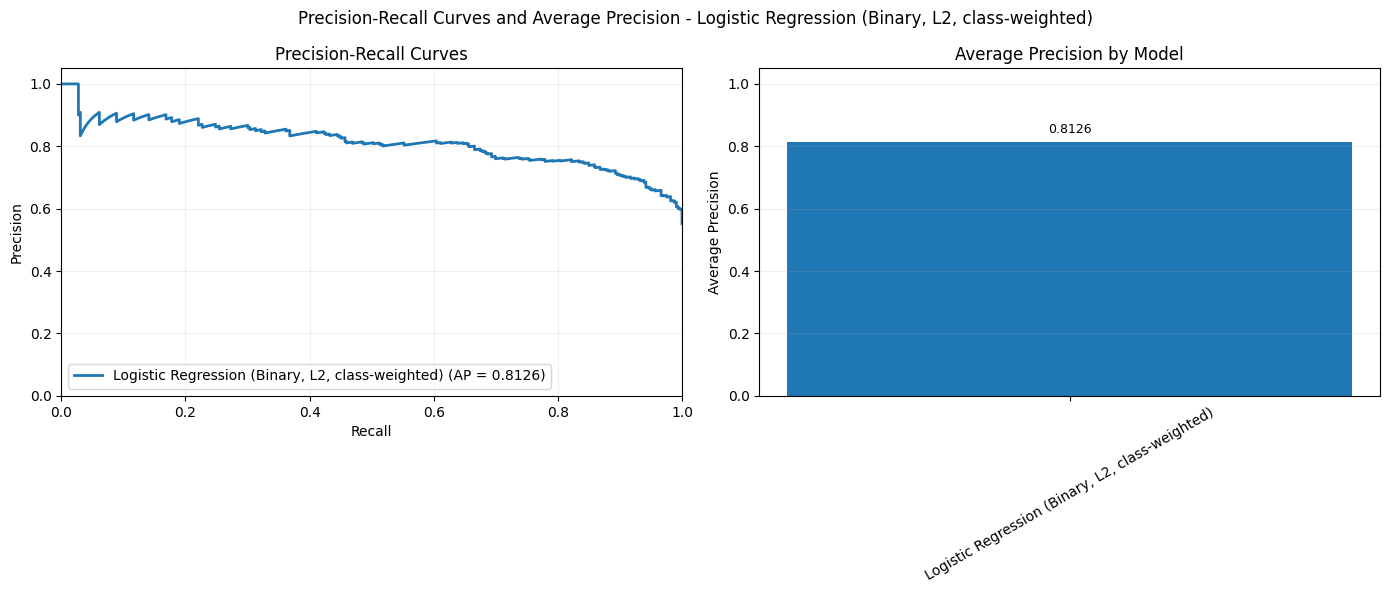

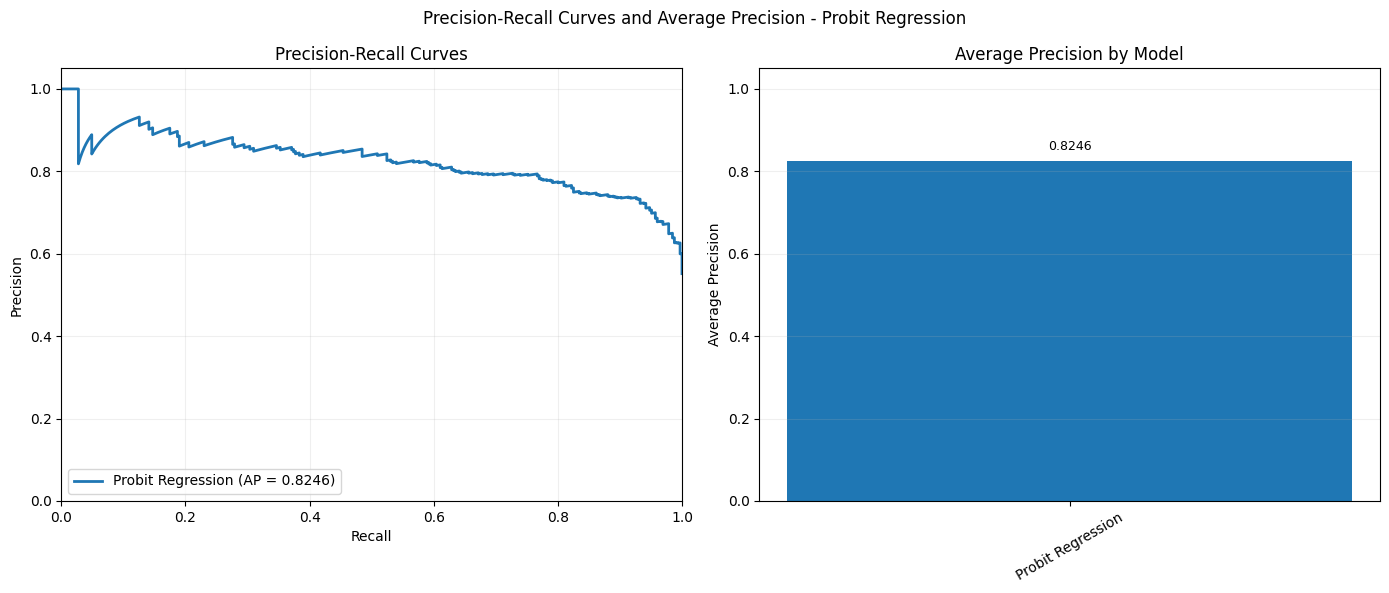

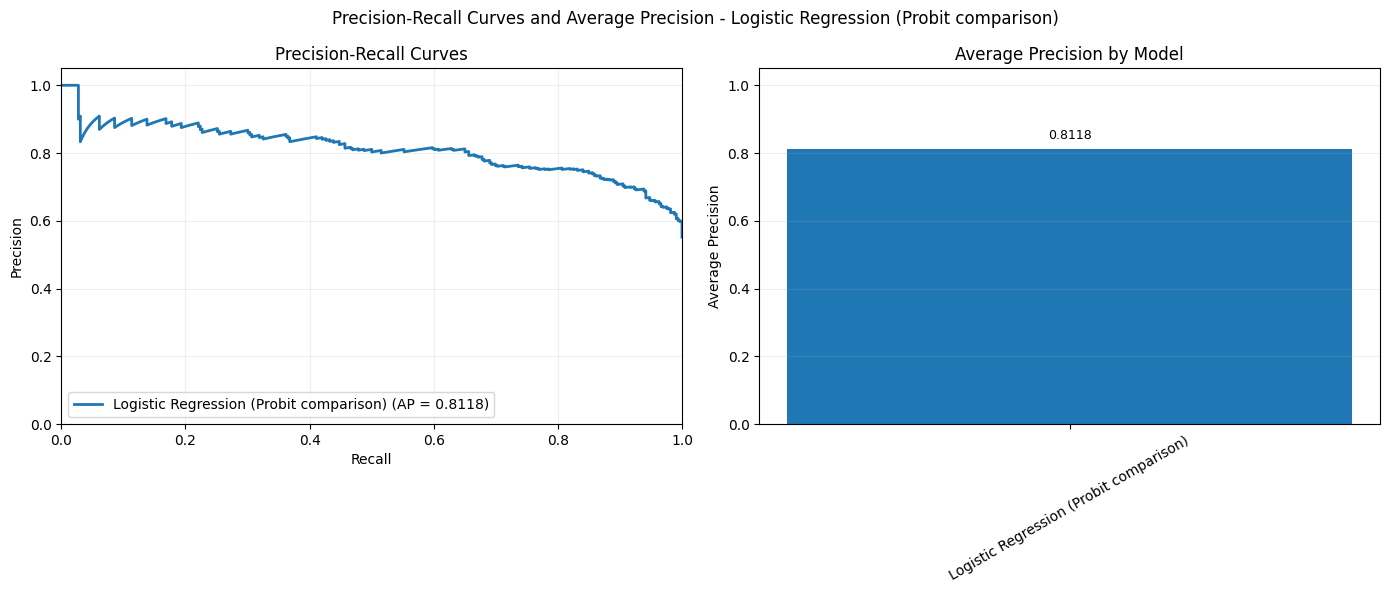

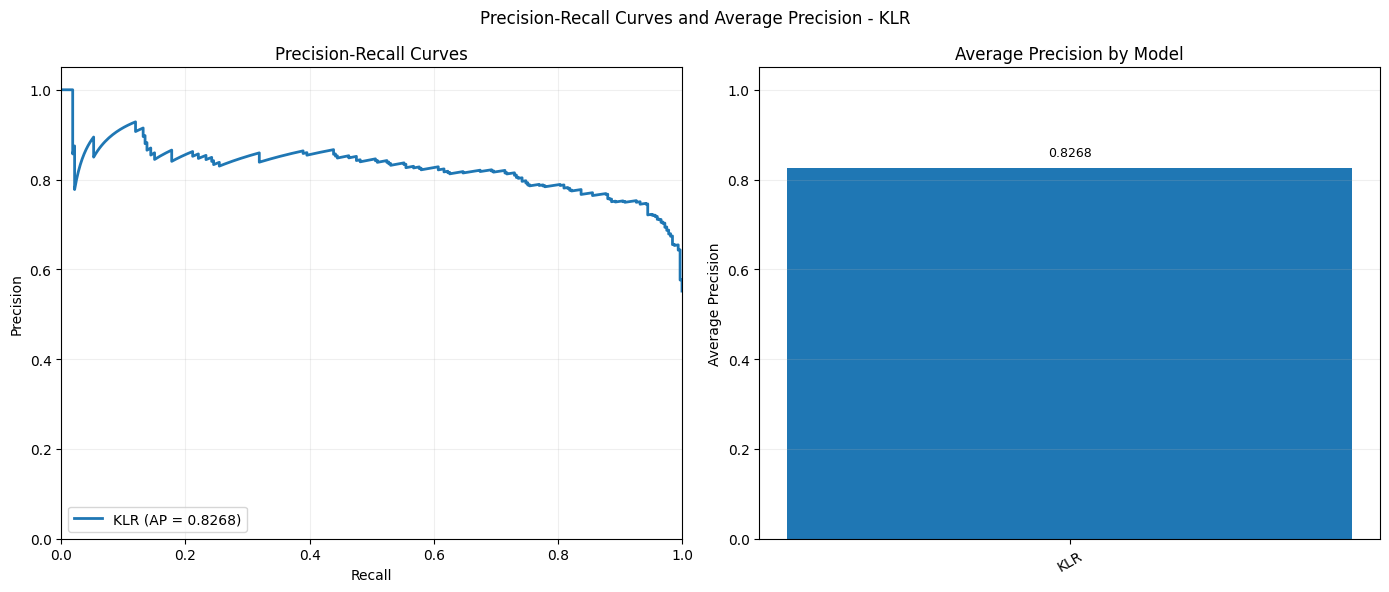


Average Precision by model:
Softmax Regression: 0.9757
QDA: 0.9697
Gaussian Naive Bayes: 0.9640
LDA: 0.9626
KLR: 0.8268
Bayesian Logistic Regression (Laplace): 0.8253
Perceptron (Binary): 0.8247
Probit Regression: 0.8246
Logistic Regression (Binary, L2, class-weighted): 0.8126
Logistic Regression (Binary): 0.8118
Logistic Regression (Probit comparison): 0.8118
Logistic Regression (Binary, L1): 0.8118
Logistic Regression (Binary, L2): 0.8118
Logistic Regression (Binary, Elastic Net): 0.8118


In [51]:
models_for_pr = {}
for name, model in models.items():
  if not hasattr(model, 'predict_proba'):
    print(f'Skip {name}: no predict_proba')
    continue

  is_binary_model = getattr(model, 'classes_', np.array([])).shape[0] == 2
  eval_X = X_test_bin if is_binary_model else X_test_scaled
  eval_y = y_test_bin if is_binary_model else y_test

  try:
    _ = model.predict_proba(eval_X[:5])
    models_for_pr[name] = (model, eval_X, eval_y)
  except Exception as e:
    print(f'Skip {name}: {e}')

if len(models_for_pr) == 0:
  raise ValueError('No valid models found for precision-recall plotting.')

ap_scores = {}
for name, (model, eval_X, eval_y) in models_for_pr.items():
  score = compare_average_precision(
    models={name: model},
    X=eval_X,
    y_true=eval_y,
    title=f'Precision-Recall Curves and Average Precision - {name}',
  )
  ap_scores.update(score)

print('\nAverage Precision by model:')
for name, score in sorted(ap_scores.items(), key=lambda x: x[1], reverse=True):
  print(f'{name}: {score:.4f}')

## 4.6 McNemar's test

**Cơ sở lý thuyết (ngắn gọn):** McNemar là kiểm định cho dữ liệu cặp (paired) trên cùng tập test, dùng để kiểm tra hai mô hình có khác biệt về tỉ lệ đúng/sai hay không.
- Giả thuyết không \(H_0\): hai mô hình có cùng xác suất sai khác trên cùng mẫu.
- Thông tin chính nằm ở hai ô bất đồng: `n01` (A sai, B đúng) và `n10` (A đúng, B sai).
- Nếu `n01 + n10` nhỏ, dùng kiểm định exact binomial; nếu đủ lớn, dùng xấp xỉ chi-square có continuity correction.
- Kết luận dựa trên `p-value` so với `alpha`.

In [52]:
perceptron_bin_preds = perceptron_clf.predict(X_test_bin)

pairs = [
  ('GNB', 'LDA', y_test, gnb_preds, lda_preds),
  ('GNB', 'QDA', y_test, gnb_preds, qda_preds),
  ('LDA', 'QDA', y_test, lda_preds, qda_preds),
  ('Softmax', 'LDA', y_test, softmax_preds, lda_preds),
  ('Softmax', 'QDA', y_test, softmax_preds, qda_preds),
  ('Perceptron (Binary)', 'LR', y_test_bin, perceptron_bin_preds, logreg_preds),
  ('Perceptron (Binary)', 'BLR', y_test_bin, perceptron_bin_preds, blr_preds),
  ('LR', 'BLR', y_test_bin, logreg_preds, blr_preds),
  ('LR-L2', 'LR-L2-balanced', y_test_bin, logreg_l2_preds, logreg_l2_balanced_preds),
]

for name1, name2, y_true_pair, preds1, preds2 in pairs:
  result = mcnemar_paired(
    y_true=y_true_pair,
    y_pred_a=preds1,
    y_pred_b=preds2,
  )

  a_correct = preds1 == y_true_pair
  b_correct = preds2 == y_true_pair
  n00 = int((~a_correct & ~b_correct).sum())
  n01 = int((~a_correct & b_correct).sum())
  n10 = int((a_correct & ~b_correct).sum())
  n11 = int((a_correct & b_correct).sum())

  p_value = float(result['pvalue'])
  method = result['method']

  print(f"\nMcNemar test between {name1} and {name2}")
  print(f"Contingency table (A={name1}, B={name2}):")
  print(f"  n00 (A wrong, B wrong): {n00}")
  print(f"  n01 (A wrong, B correct): {n01}")
  print(f"  n10 (A correct, B wrong): {n10}")
  print(f"  n11 (A correct, B correct): {n11}")
  print(f"Method: {method}")
  print(f"p-value: {p_value:.6f}")

  if p_value < ALPHA:
    print(f"Kết luận: Bác bỏ H0 ở alpha={ALPHA}. Hai mô hình khác biệt có ý nghĩa thống kê.")
  else:
    print(f"Kết luận: Chưa bác bỏ H0 ở alpha={ALPHA}. Chưa đủ bằng chứng khác biệt có ý nghĩa thống kê.")


McNemar test between GNB and LDA
Contingency table (A=GNB, B=LDA):
  n00 (A wrong, B wrong): 200
  n01 (A wrong, B correct): 75
  n10 (A correct, B wrong): 71
  n11 (A correct, B correct): 2377
Method: chi2_cc
p-value: 0.803916
Kết luận: Chưa bác bỏ H0 ở alpha=0.05. Chưa đủ bằng chứng khác biệt có ý nghĩa thống kê.

McNemar test between GNB and QDA
Contingency table (A=GNB, B=QDA):
  n00 (A wrong, B wrong): 208
  n01 (A wrong, B correct): 67
  n10 (A correct, B wrong): 45
  n11 (A correct, B correct): 2403
Method: chi2_cc
p-value: 0.047221
Kết luận: Bác bỏ H0 ở alpha=0.05. Hai mô hình khác biệt có ý nghĩa thống kê.

McNemar test between LDA and QDA
Contingency table (A=LDA, B=QDA):
  n00 (A wrong, B wrong): 217
  n01 (A wrong, B correct): 54
  n10 (A correct, B wrong): 36
  n11 (A correct, B correct): 2416
Method: chi2_cc
p-value: 0.073140
Kết luận: Chưa bác bỏ H0 ở alpha=0.05. Chưa đủ bằng chứng khác biệt có ý nghĩa thống kê.

McNemar test between Softmax and LDA
Contingency table (A

## 4.7 Phân tích Calibration của xác suất đầu ra bằng reliability diagram.

**Cơ sở lý thuyết (ngắn gọn):**
- Calibration đo mức độ “xác suất dự đoán” có khớp với tần suất thực tế hay không.
- Reliability diagram so sánh xác suất dự đoán trung bình với tỉ lệ dương tính thực nghiệm theo từng bin.
- Đường càng gần đường chéo càng tốt; ECE nhỏ hơn thường cho thấy mô hình hiệu chỉnh xác suất tốt hơn.

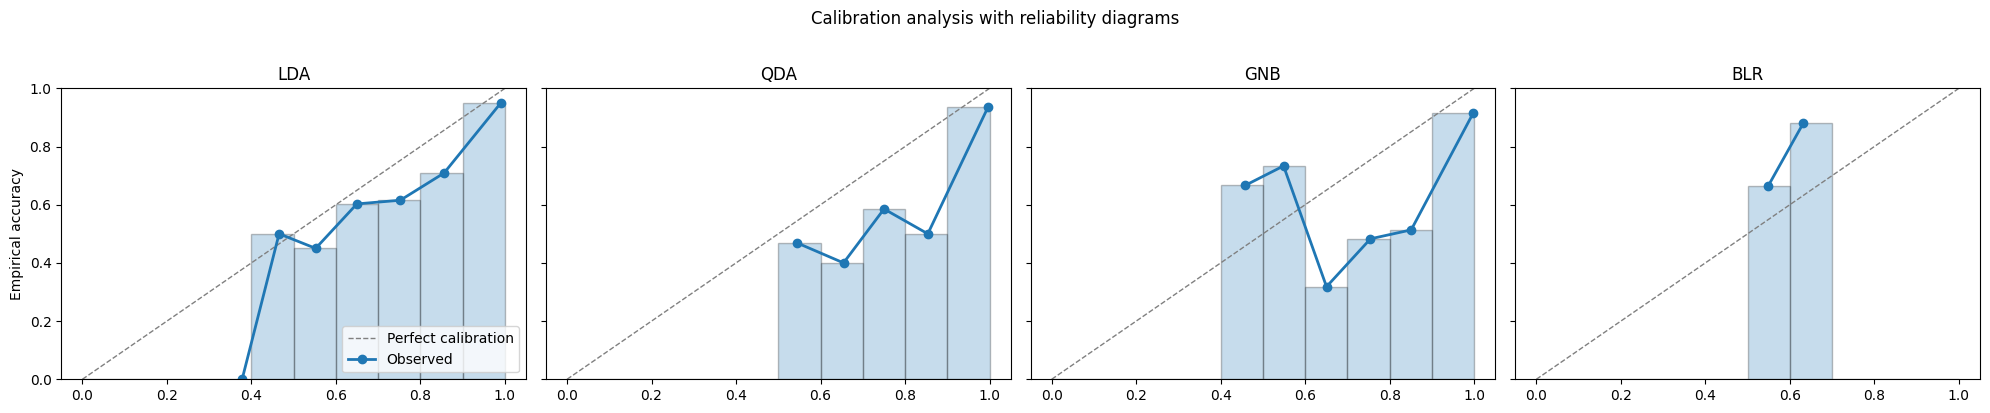

Calibration summary (lower ECE is better):
LDA: ECE=0.0517, avg_confidence=0.6635, avg_accuracy=0.5469
QDA: ECE=0.0726, avg_confidence=0.7598, avg_accuracy=0.5780
GNB: ECE=0.0907, avg_confidence=0.7101, avg_accuracy=0.6049
BLR: ECE=0.1743, avg_confidence=0.5904, avg_accuracy=0.7727


In [53]:
# Models already fitted earlier in the notebook
models_for_calibration = {
  'LDA': (lda, X_test_scaled, y_test),
  'QDA': (qda, X_test_scaled, y_test),
  'GNB': (gnb, X_test_scaled, y_test),
  'BLR': (blr, X_test_bin, y_test_bin),
}

fig, axes = plt.subplots(
  1,
  len(models_for_calibration),
  figsize=(5 * len(models_for_calibration), 4),
  sharey=True,
)

if len(models_for_calibration) == 1:
  axes = [axes]

calibration_summary = []

for ax, (model_name, payload) in zip(axes, models_for_calibration.items()):
  model, eval_X, eval_y = payload
  y_prob = model.predict_proba(eval_X)
  if y_prob.ndim == 1:
    y_prob = np.column_stack([1 - y_prob, y_prob])

  bin_centers, counts, conf_mean, acc_mean, ece = reliability_diagram_multiclass(
    y_true=eval_y,
    probs=y_prob,
    class_labels=model.classes_,
    n_bins=N_BINS,
)

  valid = ~np.isnan(conf_mean) & ~np.isnan(acc_mean)

  ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='Perfect calibration')
  ax.plot(conf_mean[valid], acc_mean[valid], marker='o', linewidth=2, label='Observed')
  ax.bar(
    bin_centers,
    np.nan_to_num(acc_mean, nan=0.0),
    width=1.0 / N_BINS,
    alpha=0.25,
    edgecolor='black',
  )
  ax.set_ylim(0, 1)
  ax.set_title(model_name)

  calibration_summary.append({
    'model': model_name,
    'ece': ece,
    'avg_confidence': float(np.nanmean(conf_mean)),
    'avg_accuracy': float(np.nanmean(acc_mean)),
  })

axes[0].set_ylabel('Empirical accuracy')
axes[0].legend(loc='lower right')
plt.suptitle('Calibration analysis with reliability diagrams', y=1.02)
plt.tight_layout()
plt.show()

calibration_summary = sorted(calibration_summary, key=lambda x: x['ece'])
print('Calibration summary (lower ECE is better):')
for row in calibration_summary:
  print(
    f"{row['model']}: "
    f"ECE={row['ece']:.4f}, "
    f"avg_confidence={row['avg_confidence']:.4f}, "
    f"avg_accuracy={row['avg_accuracy']:.4f}"
  )

## 4.8 Vẽ ROC Curve và AUC

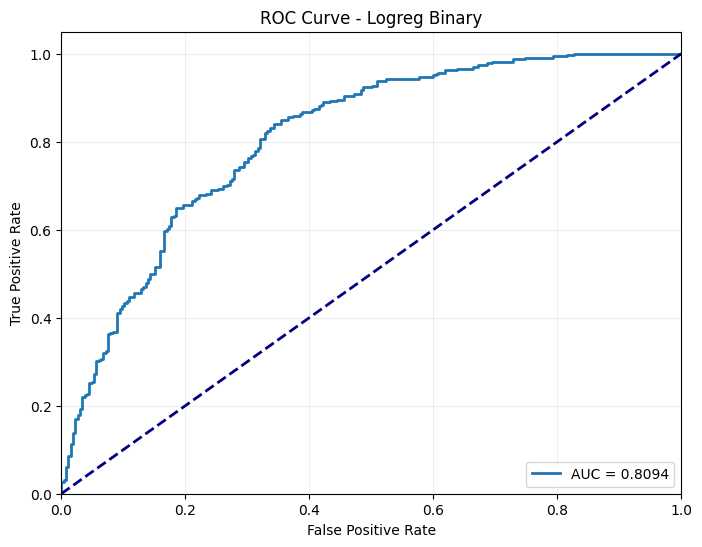

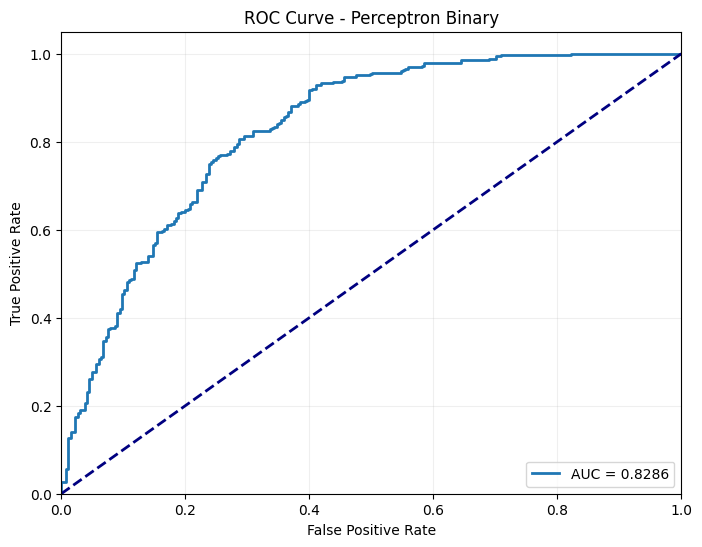

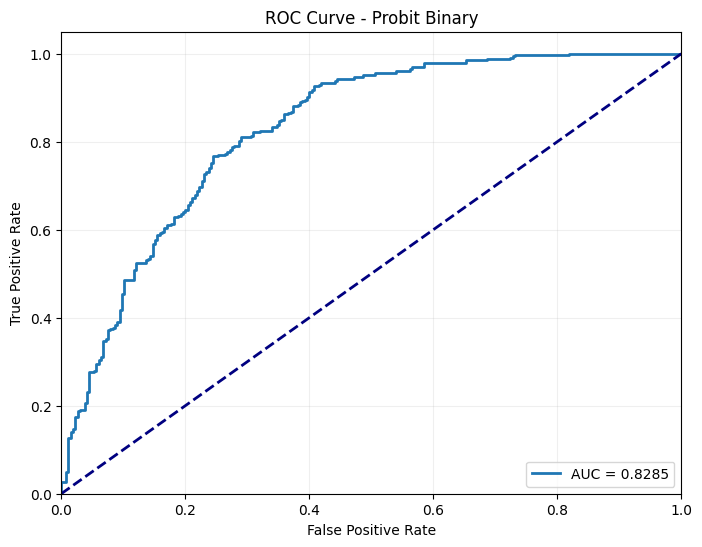

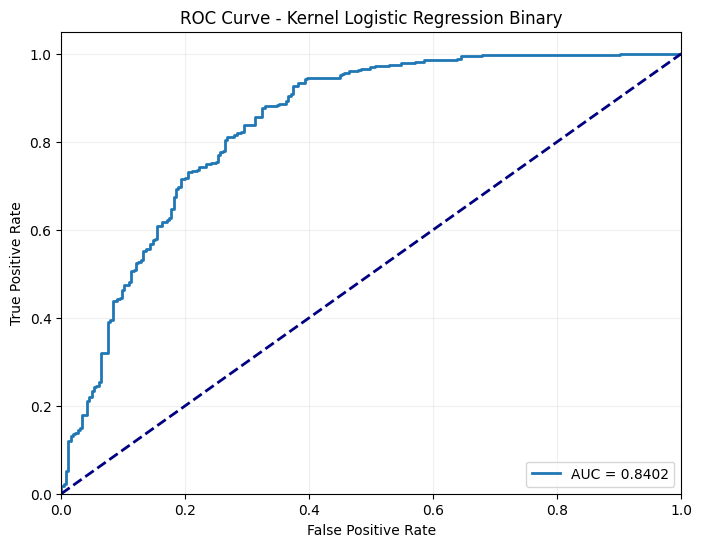

In [54]:
roc_candidates = {
  'logreg': logreg,
  'perceptron': perceptron_clf,
  'probit': probit_model,
  'kernel logistic regression': klr,
}
roc_models = collect_models_with_attr(roc_candidates, 'predict_proba')

for name, model in roc_models.items():
  try:
    plot_roc_curve(model, X_test_bin, y_test_bin, title=f'ROC Curve - {name.title()} Binary')
  except Exception as e:
    print(f'Could not plot ROC for {name}:', e)


## 6. Discussion tổng kết

Kết quả sau khi đồng bộ toàn bộ pipeline cho thấy bài toán phân lớp hiện tại có cấu trúc **không hoàn toàn tuyến tính**, nhưng mức phi tuyến chưa quá cực đoan. Trong nhóm mô hình cốt lõi, Logistic (kèm regularization), LDA/QDA và Softmax đều tạo baseline mạnh; thứ hạng giữa chúng ổn định hơn khi nhìn đồng thời trên test split, `k-fold CV` và các biểu đồ PR/ROC thay vì chỉ một chỉ số đơn lẻ.

Phần tối ưu hóa cho Logistic cho kết quả đúng với lý thuyết: Newton/IRLS giảm loss nhanh hơn theo số vòng lặp so với GD, nhưng chi phí mỗi bước cao hơn do xử lý Hessian. Vì vậy, nếu ưu tiên tốc độ hội tụ theo iteration thì Newton có lợi; nếu ưu tiên chi phí tính toán đơn giản và dễ mở rộng thì GD vẫn là lựa chọn thực dụng.

`LDA` và `QDA` là cặp cần diễn giải theo giả thiết phân phối: khi hiệp phương sai các lớp gần nhau hoặc dữ liệu mỗi lớp chưa đủ lớn, LDA thường ổn định hơn; khi biên quyết định thực sự cong và mỗi lớp có cấu trúc phân tán khác nhau rõ rệt, QDA có thể vượt lên. Fisher ratio và không gian chiếu LDA 2D là bằng chứng trực quan tốt để giải thích tại sao một số lớp dễ tách hơn các lớp còn lại.

Ở nhánh regularized Logistic, `L1`, `L2` và `Elastic Net` cho thấy tác dụng chính là kiểm soát độ phức tạp và cải thiện độ ổn định thay vì luôn tạo bước nhảy lớn về accuracy. `Class-weighted loss` đặc biệt hữu ích khi dữ liệu có mất cân bằng, vì nó dịch chuyển biên quyết định theo hướng tăng độ nhạy cho lớp thiểu số và thường phản ánh rõ hơn qua Recall/F1 và PR curve.

Các bonus models nên được đọc đúng phạm vi. `Probit` chủ yếu là đối chứng phân phối link function so với Logistic; `Laplace approximation` bổ sung góc nhìn uncertainty-aware cho mô hình phân biệt; `Kernel Logistic Regression` giúp xử lý biên phi tuyến tốt hơn nhưng đánh đổi chi phí huấn luyện và khả năng diễn giải. Vì vậy, bonus nên được trình bày như phần mở rộng có kiểm soát, không thay thế hoàn toàn kết luận chính từ nhóm mô hình nền tảng.

Tóm lại, một kết luận hợp lý cho phần classification là:
- **baseline tuyến tính** (Logistic/LDA/Softmax) vẫn là nền bắt buộc vì ổn định và dễ giải thích,
- **regularization + class-weighted loss** là cấu phần quan trọng để tăng robustness trong bối cảnh mất cân bằng,
- **QDA và Kernel Logistic** là hai hướng cải thiện khi dữ liệu thể hiện phi tuyến rõ,
- **PR/AP, calibration và McNemar** cần đi cùng Accuracy để tránh kết luận một chiều,
- **bonus models** nên được báo cáo kèm phạm vi áp dụng và chi phí tính toán để đảm bảo diễn giải công bằng.
